# 机器学习实验二：基于 PyTorch 的手写数字识别

这份 notebook 分为两部分：

1. **基线示例**  
   前半部分提供一个完整可运行的基线模型，包含数据加载、数据预处理、模型构建、训练、验证、测试和曲线绘制等流程。  
   请先完整运行这一部分，理解深度学习实验的基本流程。

2. **学生实验模板**  
   后半部分用于完成调参与对比实验。  
   请参考基线示例，在指定位置修改参数、补充代码、运行实验，并记录结果。

使用建议：

- 先从上到下运行基线示例，确认环境和代码可以正常运行。
- 再阅读封装好的训练与评估函数，理解它们在后续实验中的作用。
- 最后完成 batch size、隐藏层层数、神经元数量、激活函数和 Dropout 等单变量对比实验。
- 附加题为选做内容，可根据兴趣和时间完成。

## 0.Setup Code

In [1]:
from google.colab import drive
drive.mount("/content/drive")

import os

GOOGLE_PATH_AFTER_MYDRIVE='ML_lab/lab2'
WORK_DIR=os.path.join('/content','drive','My Drive',GOOGLE_PATH_AFTER_MYDRIVE)

print(os.listdir(WORK_DIR))
%cd $WORK_DIR
print(os.getcwd())

#%load_ext autoreload
#%autoreload 2

Mounted at /content/drive
['data', 'checkpoints', 'ml_lab2_pytorch_mnist.ipynb']
/content/drive/My Drive/ML_lab/lab2
/content/drive/My Drive/ML_lab/lab2


## 一、基线示例

目标：先跑通一个最简单的全连接 BP 神经网络。

流程：数据加载 → 数据预处理 → 模型构建 → 训练 → 验证 → 测试。


### 1. 导入库并设置设备


In [22]:
import random
import time

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from sklearn.metrics import precision_score, recall_score, f1_score
import torch.nn.functional as F
import matplotlib.pyplot as plt


# 固定随机种子，方便复现实验结果。
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


# 有 GPU 就使用 GPU，否则使用 CPU。
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("使用设备:", device)


使用设备: cuda


### 2. 数据预处理

`ToTensor()` 会把图片像素从 0 ~ 255 转成 0 ~ 1。  
这是因为神经网络更适合处理数值范围较小的数据，先缩放可以让训练更稳定。  
(0~255) / 255 -> 0~1  
MNIST中图像存储方式 : PIL 形状为(H,W,C), 即(28,28,1)  
对于Pytorch,图片通常以(C,H,W)存储,即(1,28,28)  
ToTensor()也会把图像由(H,W,C)转化为(C,H,W)的形状  

`Normalize()` 会进一步做标准化，让数据分布更合适。  
标准化后，数据不再局限于 0 ~ 1，而是变成“减去均值，再除以标准差”后的结果。  
这样通常有助于模型更快收敛，也能让不同维度的数据处于更接近的尺度上。  
Normalize接受的MEANS,STDS分别是一个元组    
对于图像的每一个通道,分别进行标准化  
由于MNIST数据集中的图片是单通道的,所以只需要传入长度为1的元组  


可以**简单理解**为：

- `ToTensor()`：先把数值变小
- `Normalize()`：再把数据调整得更适合训练

In [3]:
# MNIST 是 1 通道灰度图，所以均值和标准差都只有一个数。
MNIST_MEAN = (0.1307,)
MNIST_STD = (0.3081,)

transform = transforms.Compose([
    transforms.ToTensor(),                         # 0~255 -> 0~1
    transforms.Normalize(MNIST_MEAN, MNIST_STD),   # 标准化
])


### 3. 加载数据集并划分验证集

原始 MNIST 训练集有 60000 张图片。

这里划分为：

- 50000 张：训练集，用来更新模型参数
- 10000 张：验证集，用来调参和画曲线

测试集保留到最后使用。


In [4]:
import os
print("current working directory:",os.getcwd())
#expected:\lab2   确保读取MNIST数据集到lab2目录下

current working directory: /content/drive/My Drive/ML_lab/lab2


In [5]:
# 下载并读取 MNIST 数据集。
train_full = datasets.MNIST("./data", train=True, download=True, transform=transform)
test_dataset = datasets.MNIST("./data", train=False, download=True, transform=transform)

TRAIN_SIZE = 50000   # 用于训练
VAL_SIZE = 10000     # 用于调参与画曲线

# 使用固定随机种子划分，保证每次运行划分结果一致。
train_dataset, val_dataset = random_split(
    train_full,
    [TRAIN_SIZE, VAL_SIZE],
    generator=torch.Generator().manual_seed(SEED)
)

print("训练集样本数:", len(train_dataset))
print("验证集样本数:", len(val_dataset))
print("测试集样本数:", len(test_dataset))


训练集样本数: 50000
验证集样本数: 10000
测试集样本数: 10000


In [6]:
image,label = train_dataset[0]  #type: ignore
print("type(image):",type(image),"image.shape:",image.shape)
print("image张量的元素个数:",image.numel())
print("type(label)",type(label))

type(image): <class 'torch.Tensor'> image.shape: torch.Size([1, 28, 28])
image张量的元素个数: 784
type(label) <class 'int'>


### 4. 设置基线参数

下面这组参数用于设置**基线实验**。  
建议先使用这组参数完整运行一次，得到基线结果，作为后续对比实验的参照。

基线模型结构为：

`Flatten → Linear(784, 128) → ReLU → Linear(128, 10)`


In [ ]:
# 基线参数：不建议修改。
batch_size = 64
hidden_dim = 128
learning_rate = 0.001
epochs = 5


### 5. 创建 DataLoader

DataLoader 负责把数据按 batch 送入模型。


In [ ]:
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("每个 batch 的样本数:", batch_size)
print("训练集 batch 数量:", len(train_loader))


每个 batch 的样本数: 64
训练集 batch 数量: 782


### 6. 搭建基线 BP 神经网络模型

注意：本实验使用 `nn.CrossEntropyLoss()`，模型最后一层直接输出 logits，不需要加 `Softmax`。


In [ ]:
baseline_model = nn.Sequential(
    nn.Flatten(),                 # [batch_size, 1, 28, 28] -> [batch_size, 784]
    nn.Linear(784, hidden_dim),    # 第 1 个全连接层
    nn.ReLU(),                    # 激活函数
    nn.Linear(hidden_dim, 10),     # 输出层：10 类数字
).to(device)

print(baseline_model)


Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=128, bias=True)
  (2): ReLU()
  (3): Linear(in_features=128, out_features=10, bias=True)
)


### 7. 训练并验证基线模型

下面这段代码是最直观的训练流程。  
每个 epoch 包括：

1. 在训练集上训练模型
2. 在验证集上评估模型
3. 保存并打印本轮的 loss、accuracy 和耗时


In [ ]:
criterion = nn.CrossEntropyLoss()  #默认reduction="mean"
optimizer = optim.Adam(baseline_model.parameters(), lr=learning_rate)

# 用 history 保存每个 epoch 的结果，后面用于打印表格和画曲线。
baseline_history = {
    "epoch": [],
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "epoch_time": [],
}

for epoch in range(1, epochs + 1):
    start_time = time.time()

    # ========== 训练阶段 ==========
    baseline_model.train()

    train_loss_sum = 0.0
    train_correct = 0
    train_total = 0

    for data, target in train_loader:
        data = data.to(device)
        target = target.to(device)

        # 1. 清空上一轮梯度，避免梯度累积
        optimizer.zero_grad()

        # 2. 前向传播，得到模型输出
        output = baseline_model(data)

        # 3. 计算损失
        loss = criterion(output, target)

        # 4. 反向传播并更新参数
        loss.backward()
        optimizer.step()

        # 5. 统计本 batch 的 loss 和准确率
        train_loss_sum += loss.item() * data.size(0)  #loss是平均数,因此乘以batch_size==data.size(0)
        pred = output.argmax(dim=1)
        train_correct += (pred == target).sum().item()
        train_total += target.size(0)

    train_loss = train_loss_sum / train_total
    train_acc = 100 * train_correct / train_total

    # ========== 验证阶段 ==========
    baseline_model.eval()

    val_loss_sum = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for data, target in val_loader:
            data = data.to(device)
            target = target.to(device)

            output = baseline_model(data)
            loss = criterion(output, target)

            val_loss_sum += loss.item() * data.size(0)
            pred = output.argmax(dim=1)
            val_correct += (pred == target).sum().item()
            val_total += target.size(0)

    val_loss = val_loss_sum / val_total
    val_acc = 100 * val_correct / val_total
    epoch_time = time.time() - start_time

    # ========== 保存结果 ==========
    baseline_history["epoch"].append(epoch)
    baseline_history["train_loss"].append(train_loss)
    baseline_history["train_acc"].append(train_acc)
    baseline_history["val_loss"].append(val_loss)
    baseline_history["val_acc"].append(val_acc)
    baseline_history["epoch_time"].append(epoch_time)

    print(
        f"Epoch {epoch:02d}/{epochs} | "
        f"train_loss={train_loss:.4f}, train_acc={train_acc:.2f}% | "
        f"val_loss={val_loss:.4f}, val_acc={val_acc:.2f}% | "
        f"time={epoch_time:.2f}s"
    )

print(f"训练总耗时: {sum(baseline_history['epoch_time']):.2f} 秒")


Epoch 01/5 | train_loss=0.2787, train_acc=91.80% | val_loss=0.1593, val_acc=95.25% | time=14.28s
Epoch 02/5 | train_loss=0.1182, train_acc=96.59% | val_loss=0.1238, val_acc=96.21% | time=14.34s
Epoch 03/5 | train_loss=0.0814, train_acc=97.56% | val_loss=0.1199, val_acc=96.32% | time=14.14s
Epoch 04/5 | train_loss=0.0616, train_acc=98.08% | val_loss=0.0944, val_acc=97.10% | time=14.07s
Epoch 05/5 | train_loss=0.0468, train_acc=98.57% | val_loss=0.0860, val_acc=97.43% | time=15.38s
训练总耗时: 72.21 秒


### 8. 查看基线实验结果

报告截图建议包含：

- 每个 epoch 的输出
- 最后 3 个 epoch 的表格
- loss 曲线和 accuracy 曲线


In [ ]:
print("最后 3 个 epoch 结果：")

header = f"{'epoch':>5} | {'train_loss':>10} | {'train_acc':>9} | {'val_loss':>8} | {'val_acc':>7} | {'time(s)':>7}"
print(header)
print("-" * len(header))

start = max(0, len(baseline_history["epoch"]) - 3)
for i in range(start, len(baseline_history["epoch"])):
    print(
        f"{baseline_history['epoch'][i]:>5} | "
        f"{baseline_history['train_loss'][i]:>10.4f} | "
        f"{baseline_history['train_acc'][i]:>8.2f}% | "
        f"{baseline_history['val_loss'][i]:>8.4f} | "
        f"{baseline_history['val_acc'][i]:>6.2f}% | "
        f"{baseline_history['epoch_time'][i]:>7.2f}"
    )


最后 3 个 epoch 结果：
epoch | train_loss | train_acc | val_loss | val_acc | time(s)
-------------------------------------------------------------
    3 |     0.0814 |    97.56% |   0.1199 |  96.32% |   14.14
    4 |     0.0616 |    98.08% |   0.0944 |  97.10% |   14.07
    5 |     0.0468 |    98.57% |   0.0860 |  97.43% |   15.38


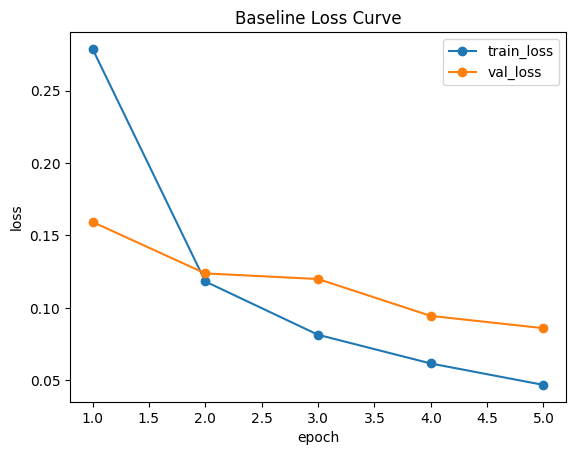

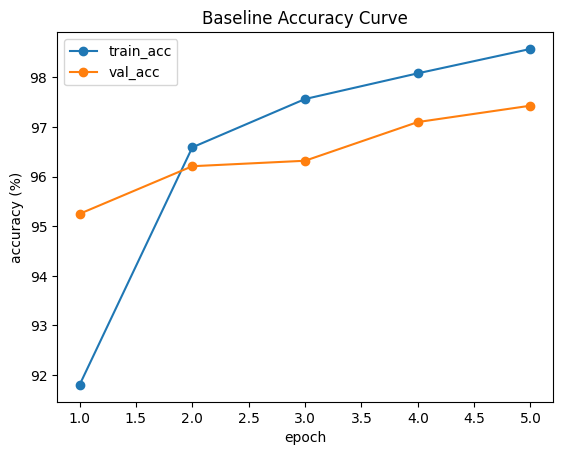

In [ ]:
# 绘制 loss 曲线
plt.figure()
plt.plot(baseline_history["epoch"], baseline_history["train_loss"], marker="o", label="train_loss")
plt.plot(baseline_history["epoch"], baseline_history["val_loss"], marker="o", label="val_loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Baseline Loss Curve")
plt.legend()
plt.show()

# 绘制 accuracy 曲线
plt.figure()
plt.plot(baseline_history["epoch"], baseline_history["train_acc"], marker="o", label="train_acc")
plt.plot(baseline_history["epoch"], baseline_history["val_acc"], marker="o", label="val_acc")
plt.xlabel("epoch")
plt.ylabel("accuracy (%)")
plt.title("Baseline Accuracy Curve")
plt.legend()
plt.show()


### 9. 在测试集上评估基线模型

调参阶段主要看验证集。  
测试集建议只在基线模型或最终选定模型上评估。


In [ ]:
baseline_model.eval()

test_loss_sum = 0.0
test_correct = 0
test_total = 0

all_targets = []
all_preds = []

with torch.no_grad():
    for data, target in test_loader:
        data = data.to(device)
        target = target.to(device)

        output = baseline_model(data)
        loss = criterion(output, target)

        test_loss_sum += loss.item() * data.size(0)

        pred = output.argmax(dim=1)

        test_correct += (pred == target).sum().item()
        test_total += target.size(0)

        all_targets.extend(target.cpu().numpy())
        all_preds.extend(pred.cpu().numpy())

baseline_test_loss = test_loss_sum / test_total
baseline_test_acc = 100 * test_correct / test_total

baseline_test_precision = precision_score(all_targets, all_preds, average='macro')
baseline_test_recall = recall_score(all_targets, all_preds, average='macro')
baseline_test_f1 = f1_score(all_targets, all_preds, average='macro')

print(f"Baseline test loss: {baseline_test_loss:.4f}")
print(f"Baseline test accuracy: {baseline_test_acc:.2f}%")
print(f"Baseline test precision (macro): {baseline_test_precision:.4f}")
print(f"Baseline test recall (macro): {baseline_test_recall:.4f}")
print(f"Baseline test f1-score (macro): {baseline_test_f1:.4f}")


Baseline test loss: 0.0772
Baseline test accuracy: 97.69%
Baseline test precision (macro): 0.9769
Baseline test recall (macro): 0.9768
Baseline test f1-score (macro): 0.9768


## 二、为了方便后续**调参**实验，封装统一实验函数

前面已经用较为直观的方式完成了一次基线实验，便于理解完整训练流程。  
为了让后续调参与对比实验更方便、代码更简洁，下面将基线实验的主要流程整理成统一实验函数 `run_experiment(...)`。

从后面的实验开始，学生主要通过**修改调用 `run_experiment(...)` 时传入的参数**来完成不同调参对比实验。


### 10. 准备几个辅助函数

下面这些函数只是把前面基线代码中的重复部分整理出来。  
一般**不需要修改**这些函数，理解它们的作用即可。


In [7]:
def set_seed(seed=SEED):
    """固定随机种子，尽量减少实验中的随机因素。"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def make_dataloaders(batch_size):
    """根据 batch_size 创建训练集、验证集和测试集 DataLoader。"""
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    return train_loader, val_loader, test_loader


def get_activation(name):
    """根据名称返回激活函数。"""
    name = name.lower()

    if name == "relu":
        return nn.ReLU()
    if name == "sigmoid":
        return nn.Sigmoid()
    if name == "tanh":
        return nn.Tanh()
    if name == "leaky_relu":
        return nn.LeakyReLU()

    raise ValueError("activation_name 只能是 relu / sigmoid / tanh / leaky_relu")


def build_mlp(hidden_dims=None, activation_name="relu", dropout_p=0.0):
    """
    构建全连接 BP 神经网络。

    参数说明：
    - hidden_dims: 隐藏层神经元数量列表，例如 [128]、[128, 128, 128]
    - activation_name: 激活函数名称
    - dropout_p: Dropout 概率，0.0 表示不使用 Dropout
    """
    if hidden_dims is None:
        hidden_dims = [128]

    layers = [nn.Flatten()]      # [batch_size, 1, 28, 28] -> [batch_size, 784]
    input_dim = 784

    for hidden_dim in hidden_dims:
        layers.append(nn.Linear(input_dim, hidden_dim))  #type: ignore
        layers.append(get_activation(activation_name))  #type: ignore

        if dropout_p > 0:
            layers.append(nn.Dropout(p=dropout_p))  #type: ignore

        input_dim = hidden_dim

    layers.append(nn.Linear(input_dim, 10)) #type: ignore  # 输出10 个 logits，对应数字 0~9
    return nn.Sequential(*layers)


### 11. 训练、评估与结果记录函数

这些函数对应基线代码中的三个动作：

- `train_one_epoch(...)`：训练一个 epoch
- `evaluate(...)`：在验证集或测试集上评估
- `record_history(...)`：把每个 epoch 的结果保存下来，后续展示


In [8]:
def train_one_epoch(model, loader, optimizer, criterion):
    """训练一个 epoch，返回训练 loss 和训练 accuracy。"""
    model.train()

    total_loss = 0.0
    correct = 0
    total = 0

    for data, target in loader:
        data = data.to(device)
        target = target.to(device)

        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * data.size(0)
        pred = output.argmax(dim=1)
        correct += (pred == target).sum().item()
        total += target.size(0)

    avg_loss = total_loss / total
    accuracy = 100 * correct / total
    return avg_loss, accuracy


def evaluate(model, loader, criterion):
    """评估模型，返回 loss 和 accuracy。"""
    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for data, target in loader:
            data = data.to(device)
            target = target.to(device)

            output = model(data)
            loss = criterion(output, target)

            total_loss += loss.item() * data.size(0)
            pred = output.argmax(dim=1)
            correct += (pred == target).sum().item()
            total += target.size(0)

    avg_loss = total_loss / total
    accuracy = 100 * correct / total
    return avg_loss, accuracy


def init_history():
    """初始化一个 history，用来保存每个 epoch 的结果。"""
    return {
        "epoch": [],
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
        "epoch_time": [],
    }


def record_history(history, epoch, train_loss, train_acc, val_loss, val_acc, epoch_time):
    """把当前 epoch 的训练/验证结果保存到 history 中。"""
    history["epoch"].append(epoch)
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["epoch_time"].append(epoch_time)


### 12. 定义统一实验函数 `run_experiment(...)`

`run_experiment(...)` 是后续调参与对比实验的统一入口。  
学生做调参实验时，主要通过**修改调用该函数时传入的参数**来完成。

注意遵守**控制变量法**：

- 每次只改变一个超参数，其他参数保持不变
- 例如比较不同 `batch_size` 时，不要同时修改 `hidden_dims`、`activation_name` 或 `dropout_p`


In [9]:
def run_experiment(
    exp_name="baseline",
    batch_size=64,
    hidden_dims=None,
    activation_name="relu",
    dropout_p=0.0,
    learning_rate=0.001,
    epochs=5,
    verbose=True,
):
    """
    运行一组实验。

    返回：
    - model: 训练好的模型
    - history: 每个 epoch 的训练/验证结果
    - test_loader: 测试集加载器，供后续最终评估使用
    """
    if hidden_dims is None:
        hidden_dims = [128]

    # 每组实验重新固定随机种子，减少随机因素影响。
    set_seed(SEED)

    # 根据参数创建数据、模型、损失函数和优化器。
    train_loader, val_loader, test_loader = make_dataloaders(batch_size)
    model = build_mlp(hidden_dims, activation_name, dropout_p).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    history = init_history()

    if verbose:
        print("=" * 72)
        print("实验名称:", exp_name)
        print("batch_size:", batch_size)
        print("hidden_dims:", hidden_dims)
        print("activation_name:", activation_name)
        print("dropout_p:", dropout_p)
        print("learning_rate:", learning_rate)
        print("epochs:", epochs)
        print("=" * 72)

    for epoch in range(1, epochs + 1):
        start_time = time.time()

        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        val_loss, val_acc = evaluate(model, val_loader, criterion)

        epoch_time = time.time() - start_time
        record_history(history, epoch, train_loss, train_acc, val_loss, val_acc, epoch_time)

        if verbose:
            print(
                f"Epoch {epoch:02d}/{epochs} | "
                f"train_loss={train_loss:.4f}, train_acc={train_acc:.2f}% | "
                f"val_loss={val_loss:.4f}, val_acc={val_acc:.2f}% | "
                f"time={epoch_time:.2f}s"
            )

    if verbose:
        print(f"训练总耗时: {sum(history['epoch_time']):.2f} 秒")

    return model, history, test_loader


### 13. 结果展示函数

这几个函数用于截图和画图：

- `print_history_table(...)`：打印最后几个 epoch 的结果表格
- `plot_history(...)`：绘制单组实验的 loss 和 accuracy 曲线
- `plot_compare(...)`：绘制多组实验的单指标对比曲线
- `plot_compare_grid(...)`：以 2×2 子图统一绘制 `train_loss / val_loss / train_acc / val_acc` 四类对比曲线


In [10]:
def print_history_table(history, last_n=None):
    """打印训练结果表格。last_n=None 表示打印全部 epoch。"""
    total_epochs = len(history["epoch"])
    start = 0 if last_n is None else max(0, total_epochs - last_n)

    header = f"{'epoch':>5} | {'train_loss':>10} | {'train_acc':>9} | {'val_loss':>8} | {'val_acc':>7} | {'time(s)':>7}"
    print(header)
    print("-" * len(header))

    for i in range(start, total_epochs):
        print(
            f"{history['epoch'][i]:>5} | "
            f"{history['train_loss'][i]:>10.4f} | "
            f"{history['train_acc'][i]:>8.2f}% | "
            f"{history['val_loss'][i]:>8.4f} | "
            f"{history['val_acc'][i]:>6.2f}% | "
            f"{history['epoch_time'][i]:>7.2f}"
        )


def plot_history(history, title_prefix=""):
    """绘制单组实验的 loss 和 accuracy 曲线。"""
    epoch_list = history["epoch"]

    plt.figure()
    plt.plot(epoch_list, history["train_loss"], marker="o", label="train_loss")
    plt.plot(epoch_list, history["val_loss"], marker="o", label="val_loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title(f"{title_prefix} Loss Curve")
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(epoch_list, history["train_acc"], marker="o", label="train_acc")
    plt.plot(epoch_list, history["val_acc"], marker="o", label="val_acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy (%)")
    plt.title(f"{title_prefix} Accuracy Curve")
    plt.legend()
    plt.show()


def plot_compare(histories, metric="val_acc", title="Compare"):
    """
    绘制多组实验的某一个指标对比曲线。

    histories 格式示例：
    {
        "batch_size=32": history_32,
        "batch_size=64": history_64,
    }
    """
    plt.figure()
    for name, history in histories.items():
        plt.plot(history["epoch"], history[metric], marker="o", label=name)

    plt.xlabel("epoch")
    plt.ylabel(metric)
    plt.title(title)
    plt.legend()
    plt.show()


def plot_compare_grid(histories, title_prefix="Compare"):
    """ 以 2×2 子图统一绘制 train/val 的 loss 与 accuracy 对比曲线。"""
    metrics = [
        ("train_loss", "Training Loss"),
        ("val_loss", "Validation Loss"),
        ("train_acc", "Training Accuracy"),
        ("val_acc", "Validation Accuracy"),
    ]

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.ravel()

    for ax, (metric, subtitle) in zip(axes, metrics):
        for name, history in histories.items():
            ax.plot(history["epoch"], history[metric], marker="o", label=name)

        ax.set_xlabel("epoch")
        ax.set_ylabel(metric)
        ax.set_title(f"{title_prefix} - {subtitle}")
        ax.legend()

    plt.tight_layout()
    plt.show()


## 三、学生调参与对比实验

从这里开始是动手完成实验的部分。  
前面已经定义好了 `run_experiment(...)`，它可以减少重复训练代码，但**不会自动替你完成所有实验**。

每个练习只给出**一组示例代码**，请你仿照示例，自己补充其余实验组，并完成结果记录、截图和分析。

实验要求：

- 遵守**控制变量法**：每次只改变一个超参数，其他参数保持与基线一致
- 要完成 `batch size / 网络深度 / 神经元数量 / 激活函数 / Dropout` 这 **5 类单变量实验**。
- **每一类实验**都要绘制 `train_loss / val_loss / train_acc / val_acc` 四类曲线。
- 完成 5 类单变量实验后，再做一次“**不同调参方向的最佳单变量结果对比**”，并绘制上述 4 类曲线。
- 将关键结果、曲线和分析写入实验报告


### 练习 1：不同 batch size 对比

要求比较：`32`、`64`、`128`。  
其他参数保持和基线一致。

下面只给出 `batch_size=32` 的示例，请仿照补充 `batch_size=64` 和 `batch_size=128`。  


In [ ]:
# 示例：batch_size = 32
model_bs32, history_bs32, _ = run_experiment(
    exp_name="batch_size=32",
    batch_size=32,          # 本练习只修改 batch_size
    hidden_dims=[128],
    activation_name="relu",
    dropout_p=0.0,
    learning_rate=0.001,
    epochs=5,
    verbose=True,
)
batch_size_histories = {}
batch_size_histories["batch_size=32"] = history_bs32
print("\n最后 3 个 epoch 结果：")
print_history_table(history_bs32, last_n=3)

"""
notes:
batch_size_histories字典的key会决定最终plot_compare中
相应曲线的label
"""


实验名称: batch_size=32
batch_size: 32
hidden_dims: [128]
activation_name: relu
dropout_p: 0.0
learning_rate: 0.001
epochs: 5
Epoch 01/5 | train_loss=0.2417, train_acc=92.76% | val_loss=0.1478, val_acc=95.60% | time=20.75s
Epoch 02/5 | train_loss=0.1080, train_acc=96.73% | val_loss=0.1181, val_acc=96.27% | time=18.68s
Epoch 03/5 | train_loss=0.0768, train_acc=97.60% | val_loss=0.1068, val_acc=96.66% | time=24.70s
Epoch 04/5 | train_loss=0.0597, train_acc=98.09% | val_loss=0.1055, val_acc=96.79% | time=19.73s
Epoch 05/5 | train_loss=0.0467, train_acc=98.52% | val_loss=0.0994, val_acc=97.01% | time=19.27s
训练总耗时: 103.13 秒

最后 3 个 epoch 结果：
epoch | train_loss | train_acc | val_loss | val_acc | time(s)
-------------------------------------------------------------
    3 |     0.0768 |    97.60% |   0.1068 |  96.66% |   24.70
    4 |     0.0597 |    98.09% |   0.1055 |  96.79% |   19.73
    5 |     0.0467 |    98.52% |   0.0994 |  97.01% |   19.27


'\nnotes:\nbatch_size_histories字典的key会决定最终plot_compare中\n相应曲线的label\n'

In [ ]:
# TODO 1：仿照上面代码，补充 batch_size = 64 的实验。
# TODO 2：仿照上面代码，补充 batch_size = 128 的实验。

"""
统一运行batch_size=64,128的实验
"""

batch_size_list=[64,128]
for batch_size in batch_size_list:
    exp_name=f"batch_size={batch_size}"
    model,history,_=run_experiment(
                exp_name=exp_name,
                batch_size=batch_size,          # 本练习只修改 batch_size
                hidden_dims=[128],
                activation_name="relu",
                dropout_p=0.0,
                learning_rate=0.001,
                epochs=5,
                verbose=True)

    batch_size_histories[exp_name] = history
    print(f"当前batch_size为: {batch_size}")
    print("\n最后 3 个 epoch 结果：")
    print_history_table(history, last_n=3)




实验名称: batch_size=64
batch_size: 64
hidden_dims: [128]
activation_name: relu
dropout_p: 0.0
learning_rate: 0.001
epochs: 5
Epoch 01/5 | train_loss=0.2787, train_acc=91.80% | val_loss=0.1593, val_acc=95.25% | time=15.02s
Epoch 02/5 | train_loss=0.1182, train_acc=96.59% | val_loss=0.1238, val_acc=96.21% | time=13.62s
Epoch 03/5 | train_loss=0.0814, train_acc=97.56% | val_loss=0.1199, val_acc=96.32% | time=14.36s
Epoch 04/5 | train_loss=0.0616, train_acc=98.08% | val_loss=0.0944, val_acc=97.10% | time=14.19s
Epoch 05/5 | train_loss=0.0468, train_acc=98.57% | val_loss=0.0860, val_acc=97.43% | time=13.79s
训练总耗时: 70.98 秒
当前batch_size为: 64

最后 3 个 epoch 结果：
epoch | train_loss | train_acc | val_loss | val_acc | time(s)
-------------------------------------------------------------
    3 |     0.0814 |    97.56% |   0.1199 |  96.32% |   14.36
    4 |     0.0616 |    98.08% |   0.0944 |  97.10% |   14.19
    5 |     0.0468 |    98.57% |   0.0860 |  97.43% |   13.79
实验名称: batch_size=128
batch_size:

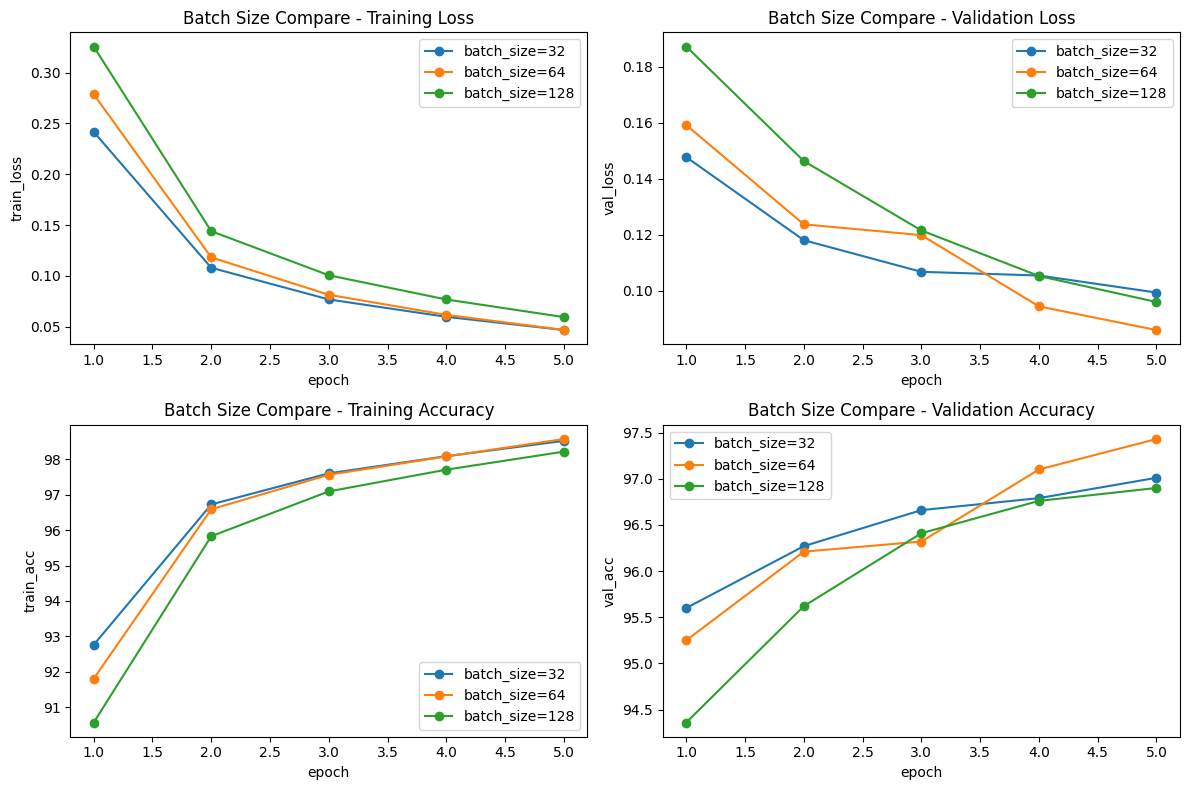

In [ ]:
# 统一绘制 4 张曲线（2×2 子图）。
plot_compare_grid(batch_size_histories, title_prefix="Batch Size Compare")


### 如何根据曲线分析结果？

| 情况 | 曲线表现 | 说明 | 可以怎么做 |
|---|---|---|---|
| 欠拟合 | `train_loss`、`val_loss` 都较高；<br>`train_acc`、`val_acc` 都较低 | 模型还没学好 | - 增加训练轮数<br>- 增大模型规模<br>- 调整学习率<br>- 适当减小 dropout |
| 过拟合 | `train_loss` 继续下降、`train_acc` 继续上升；<br>但 `val_loss` 上升或 `val_acc` 停止提升 | 模型对训练集学得太“死” | - 提前停止训练<br>- 增加 dropout<br>- 加入正则化<br>- 做数据增强<br>- 适当减小模型规模 |
| 可以继续训练 | `val_loss` 还在下降；<br>`val_acc` 还在上升 | 模型还有提升空间 | - 继续训练<br>- 继续观察验证集变化 |
| 可以考虑停止 | `val_loss` 不再下降；<br>`val_acc` 不再提升 | 模型基本达到当前效果上限 | - 停止训练<br>- 保留验证集表现最好的模型 |
| 比较不同参数 | `val_acc` 更高；`val_loss` 更低；<br>曲线更平稳 | 调参阶段主要看验证集表现 | - 选择验证集效果更好的参数设置 |


### 练习 2：不同网络深度对比

本实验中，“网络深度”用**隐藏层层数**表示。

建议比较：

- `[128]`：1 个隐藏层
- `[128, 128, 128]`：3 个隐藏层
- `[128, 128, 128, 128, 128]`：5 个隐藏层

其他参数保持和基线一致。  
下面只给出 1 个隐藏层的示例，请仿照补充 3 个隐藏层和 5 个隐藏层。  
完成后请统一绘制 `train_loss / val_loss / train_acc / val_acc` 四类曲线。


In [ ]:
# 示例：1 个隐藏层
model_depth1, history_depth1, _ = run_experiment(
    exp_name="1 hidden layer",
    batch_size=64,
    hidden_dims=[128],      # 1 个隐藏层
    activation_name="relu",
    dropout_p=0.0,
    learning_rate=0.001,
    epochs=5,
    verbose=True,
)
depth_histories={}
depth_histories["1 hidden layer"] = history_depth1
print("\n最后 3 个 epoch 结果：")
print_history_table(history_depth1, last_n=3)



实验名称: 1 hidden layer
batch_size: 64
hidden_dims: [128]
activation_name: relu
dropout_p: 0.0
learning_rate: 0.001
epochs: 5
Epoch 01/5 | train_loss=0.2787, train_acc=91.80% | val_loss=0.1593, val_acc=95.25% | time=22.23s
Epoch 02/5 | train_loss=0.1182, train_acc=96.59% | val_loss=0.1238, val_acc=96.21% | time=16.16s
Epoch 03/5 | train_loss=0.0814, train_acc=97.56% | val_loss=0.1199, val_acc=96.32% | time=18.69s
Epoch 04/5 | train_loss=0.0616, train_acc=98.08% | val_loss=0.0944, val_acc=97.10% | time=19.99s
Epoch 05/5 | train_loss=0.0468, train_acc=98.57% | val_loss=0.0860, val_acc=97.43% | time=20.45s
训练总耗时: 97.51 秒

最后 3 个 epoch 结果：
epoch | train_loss | train_acc | val_loss | val_acc | time(s)
-------------------------------------------------------------
    3 |     0.0814 |    97.56% |   0.1199 |  96.32% |   18.69
    4 |     0.0616 |    98.08% |   0.0944 |  97.10% |   19.99
    5 |     0.0468 |    98.57% |   0.0860 |  97.43% |   20.45


In [ ]:
# TODO 1：补充 3 个隐藏层的实验。
# TODO 2：补充 5 个隐藏层的实验。

depth_list=[3,5]
for depth in depth_list:
    exp_name=f"{depth} hidden layer"
    model, history ,_= run_experiment(
    exp_name=exp_name,
    batch_size=64,
    hidden_dims=[128]*depth,      # depth 个隐藏层
    activation_name="relu",
    dropout_p=0.0,
    learning_rate=0.001,
    epochs=5,
    verbose=True,
)

    depth_histories[exp_name] = history
    print(f"当前隐藏层层数: {depth}")
    print("\n最后 3 个 epoch 结果：")
    print_history_table(history, last_n=3)

实验名称: 3 hidden layer
batch_size: 64
hidden_dims: [128, 128, 128]
activation_name: relu
dropout_p: 0.0
learning_rate: 0.001
epochs: 5
Epoch 01/5 | train_loss=0.2863, train_acc=91.35% | val_loss=0.1671, val_acc=94.91% | time=21.71s
Epoch 02/5 | train_loss=0.1194, train_acc=96.28% | val_loss=0.1343, val_acc=95.99% | time=20.15s
Epoch 03/5 | train_loss=0.0863, train_acc=97.27% | val_loss=0.1145, val_acc=96.61% | time=14.52s
Epoch 04/5 | train_loss=0.0641, train_acc=97.95% | val_loss=0.1024, val_acc=97.08% | time=21.67s
Epoch 05/5 | train_loss=0.0519, train_acc=98.29% | val_loss=0.0995, val_acc=97.29% | time=21.81s
训练总耗时: 99.86 秒
当前隐藏层层数: 3

最后 3 个 epoch 结果：
epoch | train_loss | train_acc | val_loss | val_acc | time(s)
-------------------------------------------------------------
    3 |     0.0863 |    97.27% |   0.1145 |  96.61% |   14.52
    4 |     0.0641 |    97.95% |   0.1024 |  97.08% |   21.67
    5 |     0.0519 |    98.29% |   0.0995 |  97.29% |   21.81
实验名称: 5 hidden layer
batch_s

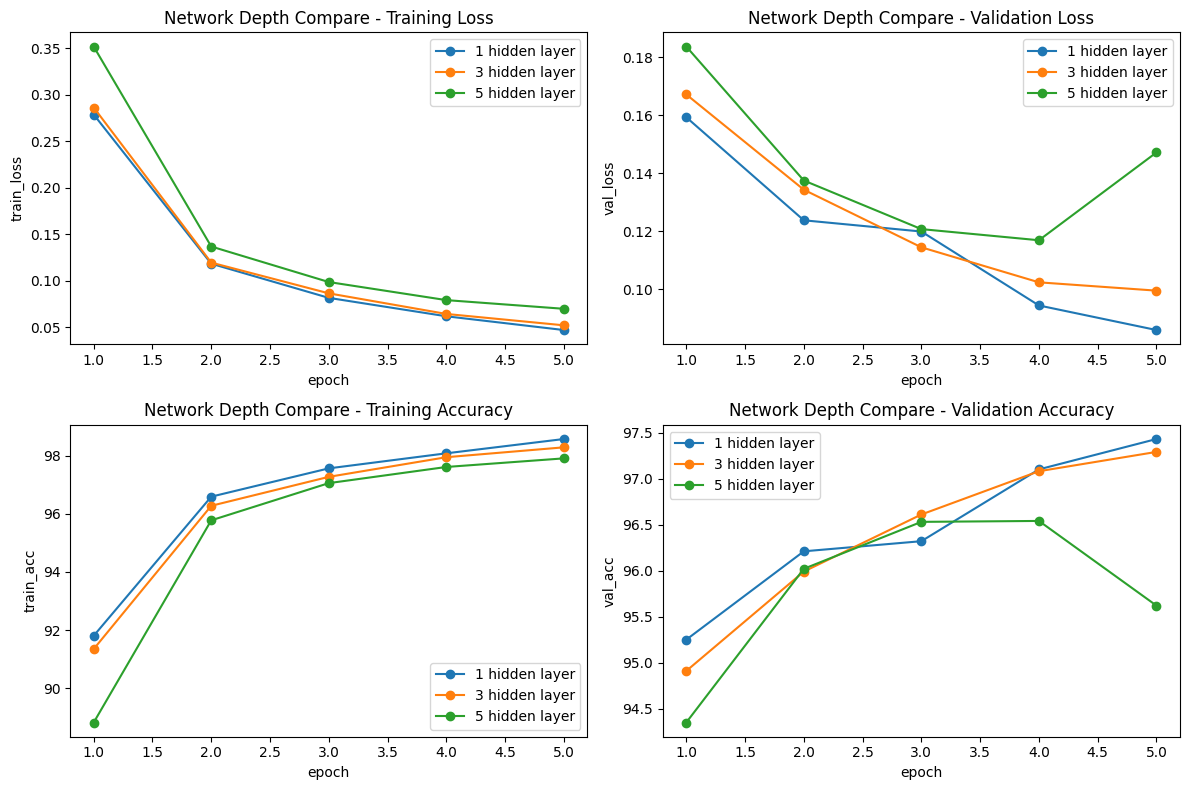

In [ ]:
# 统一绘制 4 张曲线（2×2 子图）。
plot_compare_grid(depth_histories, title_prefix="Network Depth Compare")


### 练习 3：不同神经元数量对比

要求比较：`64`、`128`、`256`、`512`。  
这里保持 1 个隐藏层，只改变隐藏层神经元数量。

下面只给出 `hidden_dims=[64]` 的示例，请仿照补充其他神经元数量。  
完成后请统一绘制 `train_loss / val_loss / train_acc / val_acc` 四类曲线。


In [ ]:
# 示例：隐藏层神经元数量为 64
model_width64, history_width64, _ = run_experiment(
    exp_name="hidden_dim=64",
    batch_size=64,
    hidden_dims=[64],       # 本练习只修改隐藏层神经元数量
    activation_name="relu",
    dropout_p=0.0,
    learning_rate=0.001,
    epochs=5,
    verbose=True,
)
width_histories = {}
width_histories["hidden_dim=64"] = history_width64
print("\n最后 3 个 epoch 结果：")
print_history_table(history_width64, last_n=3)



实验名称: hidden_dim=64
batch_size: 64
hidden_dims: [64]
activation_name: relu
dropout_p: 0.0
learning_rate: 0.001
epochs: 5
Epoch 01/5 | train_loss=0.3186, train_acc=90.89% | val_loss=0.1987, val_acc=94.17% | time=15.83s
Epoch 02/5 | train_loss=0.1530, train_acc=95.44% | val_loss=0.1554, val_acc=95.12% | time=15.15s
Epoch 03/5 | train_loss=0.1108, train_acc=96.64% | val_loss=0.1268, val_acc=96.18% | time=15.19s
Epoch 04/5 | train_loss=0.0881, train_acc=97.34% | val_loss=0.1149, val_acc=96.66% | time=15.21s
Epoch 05/5 | train_loss=0.0706, train_acc=97.91% | val_loss=0.1113, val_acc=96.74% | time=16.63s
训练总耗时: 78.01 秒

最后 3 个 epoch 结果：
epoch | train_loss | train_acc | val_loss | val_acc | time(s)
-------------------------------------------------------------
    3 |     0.1108 |    96.64% |   0.1268 |  96.18% |   15.19
    4 |     0.0881 |    97.34% |   0.1149 |  96.66% |   15.21
    5 |     0.0706 |    97.91% |   0.1113 |  96.74% |   16.63


In [ ]:
# TODO 1：仿照上面代码，补充 hidden_dims=[128] 的实验。
# TODO 2：仿照上面代码，补充 hidden_dims=[256] 的实验。
# TODO 3：仿照上面代码，补充 hidden_dims=[512] 的实验。

hidden_dim_list = [128,256,512]
for hidden_dim in hidden_dim_list:
  exp_name=f"hidden_dim={hidden_dim}"
  model, history, _ = run_experiment(
    exp_name=exp_name,
    batch_size=64,
    hidden_dims=[hidden_dim],       # 本练习只修改隐藏层神经元数量
    activation_name="relu",
    dropout_p=0.0,
    learning_rate=0.001,
    epochs=5,
    verbose=True,
)
  width_histories[exp_name] = history
  print(f"隐藏层神经元数量为 ",hidden_dim)
  print("\n最后 3 个 epoch 结果：")
  print_history_table(history, last_n=3)





实验名称: hidden_dim=128
batch_size: 64
hidden_dims: [128]
activation_name: relu
dropout_p: 0.0
learning_rate: 0.001
epochs: 5
Epoch 01/5 | train_loss=0.2787, train_acc=91.80% | val_loss=0.1593, val_acc=95.25% | time=15.95s
Epoch 02/5 | train_loss=0.1182, train_acc=96.59% | val_loss=0.1238, val_acc=96.21% | time=14.80s
Epoch 03/5 | train_loss=0.0814, train_acc=97.56% | val_loss=0.1199, val_acc=96.32% | time=15.53s
Epoch 04/5 | train_loss=0.0616, train_acc=98.08% | val_loss=0.0944, val_acc=97.10% | time=14.99s
Epoch 05/5 | train_loss=0.0468, train_acc=98.57% | val_loss=0.0860, val_acc=97.43% | time=14.94s
训练总耗时: 76.21 秒
隐藏层神经元数量为  128

最后 3 个 epoch 结果：
epoch | train_loss | train_acc | val_loss | val_acc | time(s)
-------------------------------------------------------------
    3 |     0.0814 |    97.56% |   0.1199 |  96.32% |   15.53
    4 |     0.0616 |    98.08% |   0.0944 |  97.10% |   14.99
    5 |     0.0468 |    98.57% |   0.0860 |  97.43% |   14.94
实验名称: hidden_dim=256
batch_size: 6

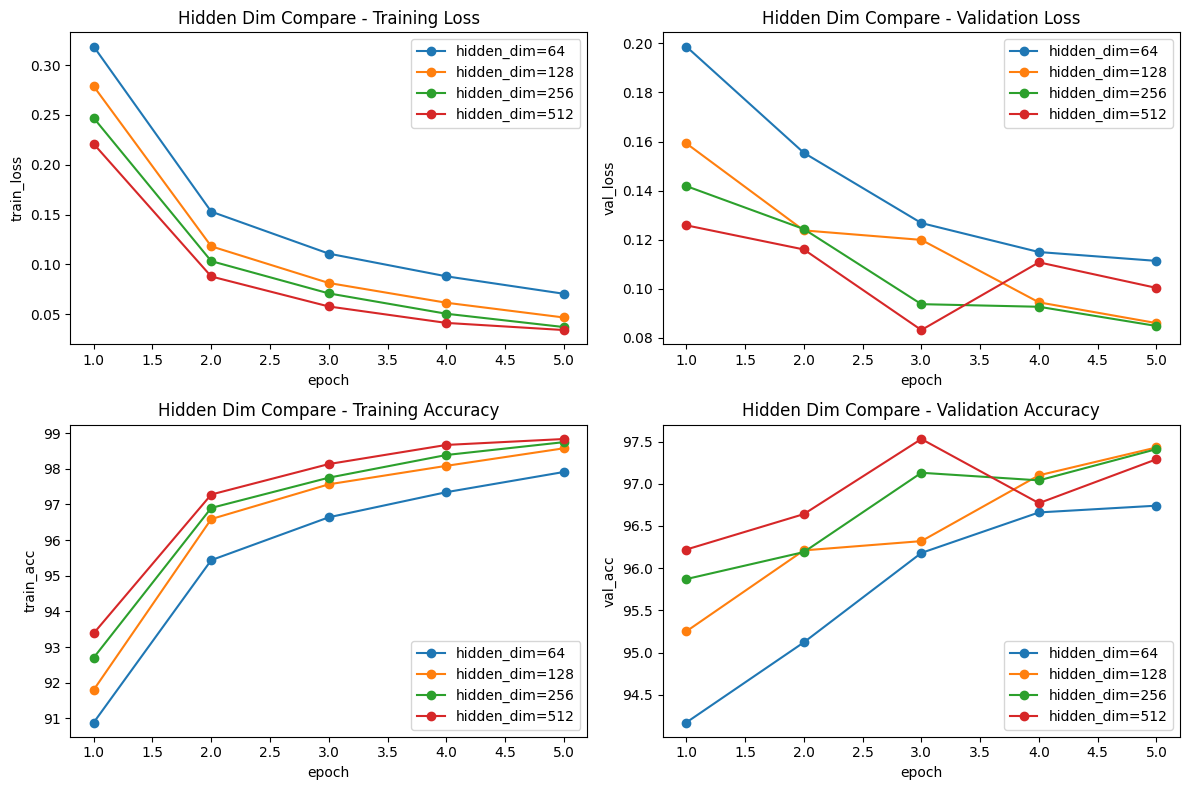

In [ ]:
# 统一绘制 4 张曲线（2×2 子图）。
plot_compare_grid(width_histories, title_prefix="Hidden Dim Compare")


### 练习 4：不同激活函数对比

建议比较：`relu`、`sigmoid`、`tanh`、`leaky_relu`。  
其他参数保持和基线一致。

下面只给出 `relu` 的示例，请仿照补充其他激活函数。  
完成后请统一绘制 `train_loss / val_loss / train_acc / val_acc` 四类曲线。


In [ ]:
# 示例：激活函数为 relu
model_relu, history_relu, _ = run_experiment(
    exp_name="activation=relu",
    batch_size=64,
    hidden_dims=[128],
    activation_name="relu",     # 本练习只修改激活函数
    dropout_p=0.0,
    learning_rate=0.001,
    epochs=5,
    verbose=True,
)
activation_histories = {}
activation_histories["activation=relu"] = history_relu
print("\n最后 3 个 epoch 结果：")
print_history_table(history_relu, last_n=3)



实验名称: activation=relu
batch_size: 64
hidden_dims: [128]
activation_name: relu
dropout_p: 0.0
learning_rate: 0.001
epochs: 5
Epoch 01/5 | train_loss=0.2787, train_acc=91.80% | val_loss=0.1593, val_acc=95.25% | time=13.53s
Epoch 02/5 | train_loss=0.1182, train_acc=96.59% | val_loss=0.1238, val_acc=96.21% | time=13.44s
Epoch 03/5 | train_loss=0.0814, train_acc=97.56% | val_loss=0.1199, val_acc=96.32% | time=13.35s
Epoch 04/5 | train_loss=0.0616, train_acc=98.08% | val_loss=0.0944, val_acc=97.10% | time=13.43s
Epoch 05/5 | train_loss=0.0468, train_acc=98.57% | val_loss=0.0860, val_acc=97.43% | time=13.34s
训练总耗时: 67.09 秒

最后 3 个 epoch 结果：
epoch | train_loss | train_acc | val_loss | val_acc | time(s)
-------------------------------------------------------------
    3 |     0.0814 |    97.56% |   0.1199 |  96.32% |   13.35
    4 |     0.0616 |    98.08% |   0.0944 |  97.10% |   13.43
    5 |     0.0468 |    98.57% |   0.0860 |  97.43% |   13.34


In [ ]:
# TODO 1：仿照上面代码，补充 activation_name="sigmoid" 的实验。
# TODO 2：仿照上面代码，补充 activation_name="tanh" 的实验。
# TODO 3：仿照上面代码，补充 activation_name="leaky_relu" 的实验。

activation_list = ['sigmoid','tanh','leaky_relu']
for activation_name in activation_list:
  exp_name=f"activation={activation_name}"
  model, history, _ = run_experiment(
      exp_name=exp_name,
      batch_size=64,
      hidden_dims=[128],
      activation_name=activation_name,     # 本练习只修改激活函数
      dropout_p=0.0,
      learning_rate=0.001,
      epochs=5,
      verbose=True,
  )

  activation_histories[exp_name] = history
  print("激活函数为",activation_name)
  print("\n最后 3 个 epoch 结果：")
  print_history_table(history, last_n=3)

实验名称: activation=sigmoid
batch_size: 64
hidden_dims: [128]
activation_name: sigmoid
dropout_p: 0.0
learning_rate: 0.001
epochs: 5
Epoch 01/5 | train_loss=0.4314, train_acc=89.02% | val_loss=0.2515, val_acc=92.68% | time=13.39s
Epoch 02/5 | train_loss=0.1965, train_acc=94.39% | val_loss=0.1939, val_acc=94.34% | time=13.31s
Epoch 03/5 | train_loss=0.1449, train_acc=95.93% | val_loss=0.1612, val_acc=95.21% | time=13.30s
Epoch 04/5 | train_loss=0.1133, train_acc=96.90% | val_loss=0.1390, val_acc=95.96% | time=13.33s
Epoch 05/5 | train_loss=0.0907, train_acc=97.52% | val_loss=0.1261, val_acc=96.19% | time=13.43s
训练总耗时: 66.75 秒
激活函数为 sigmoid

最后 3 个 epoch 结果：
epoch | train_loss | train_acc | val_loss | val_acc | time(s)
-------------------------------------------------------------
    3 |     0.1449 |    95.93% |   0.1612 |  95.21% |   13.30
    4 |     0.1133 |    96.90% |   0.1390 |  95.96% |   13.33
    5 |     0.0907 |    97.52% |   0.1261 |  96.19% |   13.43
实验名称: activation=tanh
batch_

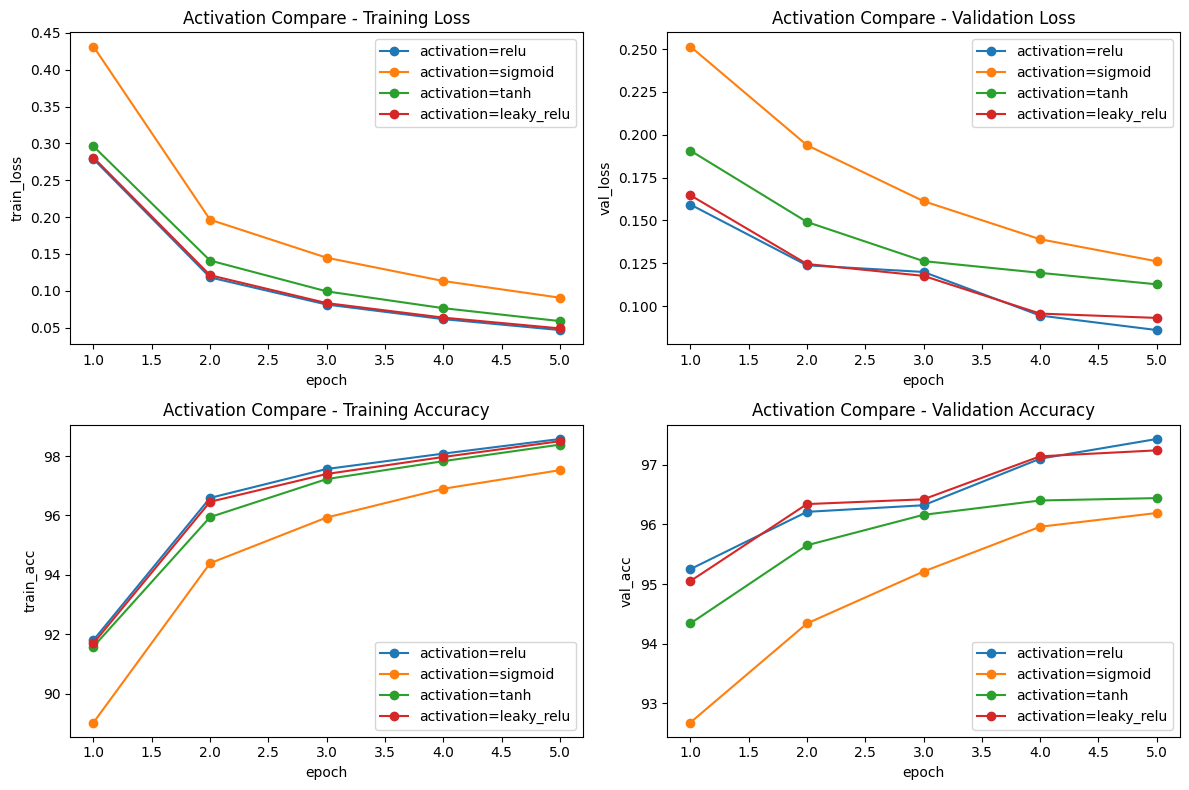

In [ ]:
# 统一绘制 4 张曲线（2×2 子图）。
plot_compare_grid(activation_histories, title_prefix="Activation Compare")


### 练习 5：Dropout 对比

建议比较：无 Dropout、`p=0.2`、`p=0.5`。  
观察训练集与验证集之间的差距，分析是否出现过拟合。

下面只给出无 Dropout 的示例，请仿照补充 `p=0.2` 和 `p=0.5`。  
完成后请统一绘制 `train_loss / val_loss / train_acc / val_acc` 四类曲线，并重点关注 `train-val` 的差距。


In [ ]:
# 示例：无 Dropout
model_dropout0, history_dropout0, _ = run_experiment(
    exp_name="dropout_p=0.0",
    batch_size=64,
    hidden_dims=[128],
    activation_name="relu",
    dropout_p=0.0,          # 本练习只修改 dropout_p
    learning_rate=0.001,
    epochs=5,
    verbose=True,
)
dropout_histories = {}
dropout_histories["dropout_p=0.0"] = history_dropout0
print("\n最后 3 个 epoch 结果：")
print_history_table(history_dropout0, last_n=3)


实验名称: dropout_p=0.0
batch_size: 64
hidden_dims: [128]
activation_name: relu
dropout_p: 0.0
learning_rate: 0.001
epochs: 5
Epoch 01/5 | train_loss=0.2787, train_acc=91.80% | val_loss=0.1593, val_acc=95.25% | time=16.45s
Epoch 02/5 | train_loss=0.1182, train_acc=96.59% | val_loss=0.1238, val_acc=96.21% | time=16.15s
Epoch 03/5 | train_loss=0.0814, train_acc=97.56% | val_loss=0.1199, val_acc=96.32% | time=15.75s
Epoch 04/5 | train_loss=0.0616, train_acc=98.08% | val_loss=0.0944, val_acc=97.10% | time=16.07s
Epoch 05/5 | train_loss=0.0468, train_acc=98.57% | val_loss=0.0860, val_acc=97.43% | time=15.62s
训练总耗时: 80.03 秒

最后 3 个 epoch 结果：
epoch | train_loss | train_acc | val_loss | val_acc | time(s)
-------------------------------------------------------------
    3 |     0.0814 |    97.56% |   0.1199 |  96.32% |   15.75
    4 |     0.0616 |    98.08% |   0.0944 |  97.10% |   16.07
    5 |     0.0468 |    98.57% |   0.0860 |  97.43% |   15.62


In [ ]:
# TODO 1：仿照上面代码，补充 dropout_p=0.2 的实验。
# TODO 2：仿照上面代码，补充 dropout_p=0.5 的实验。

dropout_p_list = [0.2,0.5]
for dropout_p in dropout_p_list:
  exp_name=f"dropout_p={dropout_p}"
  model, history, _ = run_experiment(
    exp_name=exp_name,
    batch_size=64,
    hidden_dims=[128],
    activation_name="relu",
    dropout_p=dropout_p,          # 本练习只修改 dropout_p
    learning_rate=0.001,
    epochs=5,
    verbose=True,
)
  dropout_histories[exp_name] = history
  print("丢弃率为",dropout_p)
  print("\n最后 3 个 epoch 结果：")
  print_history_table(history, last_n=3)



实验名称: dropout_p=0.2
batch_size: 64
hidden_dims: [128]
activation_name: relu
dropout_p: 0.2
learning_rate: 0.001
epochs: 5
Epoch 01/5 | train_loss=0.3107, train_acc=90.78% | val_loss=0.1677, val_acc=94.97% | time=15.71s
Epoch 02/5 | train_loss=0.1510, train_acc=95.46% | val_loss=0.1295, val_acc=96.11% | time=15.79s
Epoch 03/5 | train_loss=0.1160, train_acc=96.43% | val_loss=0.1191, val_acc=96.20% | time=15.76s
Epoch 04/5 | train_loss=0.0953, train_acc=97.05% | val_loss=0.1018, val_acc=96.90% | time=15.89s
Epoch 05/5 | train_loss=0.0830, train_acc=97.46% | val_loss=0.0920, val_acc=97.23% | time=16.15s
训练总耗时: 79.31 秒
丢弃率为 0.2

最后 3 个 epoch 结果：
epoch | train_loss | train_acc | val_loss | val_acc | time(s)
-------------------------------------------------------------
    3 |     0.1160 |    96.43% |   0.1191 |  96.20% |   15.76
    4 |     0.0953 |    97.05% |   0.1018 |  96.90% |   15.89
    5 |     0.0830 |    97.46% |   0.0920 |  97.23% |   16.15
实验名称: dropout_p=0.5
batch_size: 64
hidden

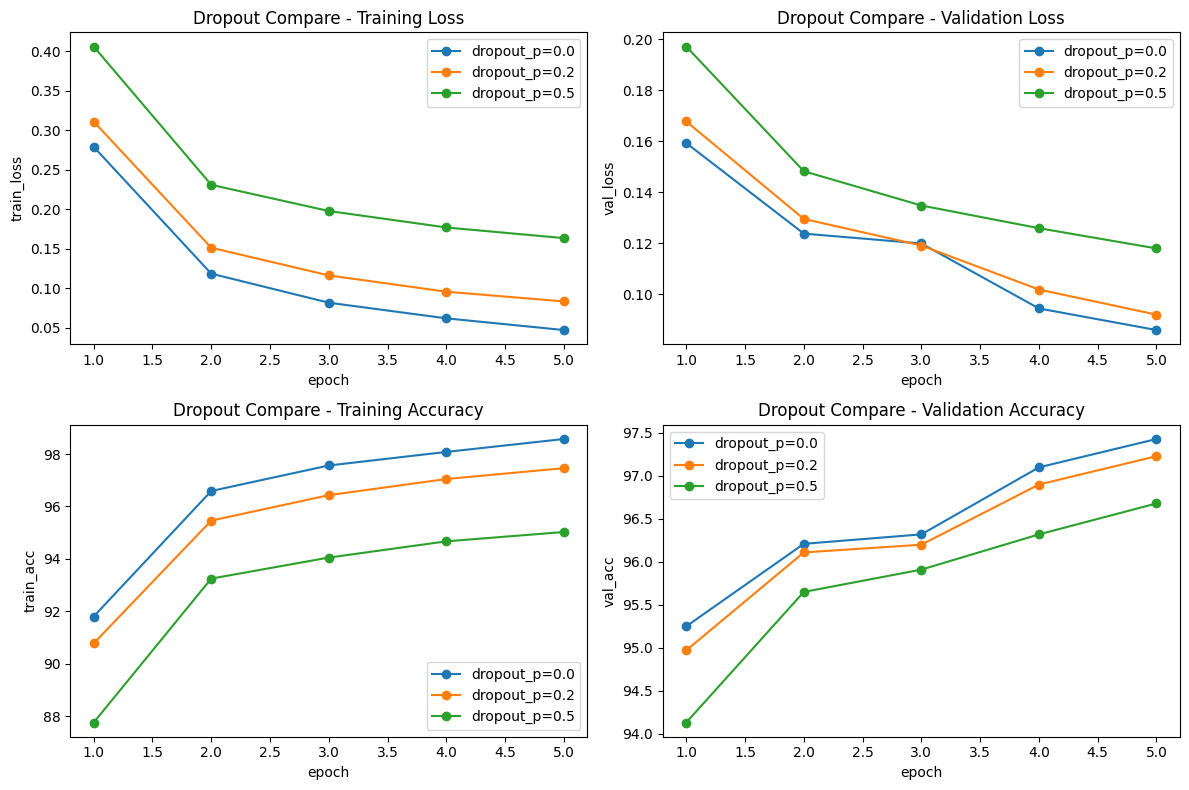

In [ ]:
# 统一绘制 4 张曲线（2×2 子图），并结合 train-val 差距分析是否过拟合。
plot_compare_grid(dropout_histories, title_prefix="Dropout Compare")


### 练习 6：不同调参方向的最佳单变量结果对比

在每一类单变量实验中，请根据验证集结果选出该类表现最好的设置。

例如：
- batch size 中选出最优的一个
- 网络深度中选出最优的一个
- 神经元数量中选出最优的一个
- 激活函数中选出最优的一个
- Dropout 中选出最优的一个

然后将这些“最佳单变量结果”放在一起绘制对比曲线，比较不同调参方向对模型性能的影响。

建议继续绘制：
- 训练损失曲线
- 验证损失曲线
- 训练准确率曲线
- 验证准确率曲线

**说明：若不同调参方向的最佳设置恰好相同，或者某个方向的最佳设置与基线相同，部分曲线可能重合，这是正常现象。**


In [11]:
# TODO：将你已经完成的实验 history 放入 histories 字典中，然后绘图。
# 例如，如果你完成了 batch_size / depth / width / activation / dropout 五类实验，
# 就把每一类“验证集表现最好的那一组” history 放进来。

#由于多次运行notebook,上次信息丢失,此处重新按照之前参数训练最好的模型
"""目前最佳参数配置:
batch_size=64
depth_size=1
hidden_dim=256
dropout_p=0.0
activation=relu

基线参数:
batch_size = 64
hidden_dim = 128
learning_rate = 0.001
epochs = 5

"""

histories = {
    # TODO ：请按你自己实验中“每个调参方向的最佳单变量结果”修改下面的标签和 history 变量。
    "batch_size=64": None,
    "depth_size=1":  None,
    "hidden_dim=256" :  None,
    "dropout_p=0.0" :  None,
    "activation=relu" :  None,
}
#batch_size=64
model,history_bs_64,_=run_experiment(
                exp_name="batch_size=64",
                batch_size=64,          # batch_size = 64
                hidden_dims=[128],
                activation_name="relu",
                dropout_p=0.0,
                learning_rate=0.001,
                epochs=5,
                verbose=True)
histories["batch_size=64"]=history_bs_64




实验名称: batch_size=64
batch_size: 64
hidden_dims: [128]
activation_name: relu
dropout_p: 0.0
learning_rate: 0.001
epochs: 5
Epoch 01/5 | train_loss=0.2787, train_acc=91.80% | val_loss=0.1592, val_acc=95.27% | time=20.21s
Epoch 02/5 | train_loss=0.1184, train_acc=96.57% | val_loss=0.1242, val_acc=96.18% | time=16.21s
Epoch 03/5 | train_loss=0.0815, train_acc=97.55% | val_loss=0.1148, val_acc=96.45% | time=14.76s
Epoch 04/5 | train_loss=0.0609, train_acc=98.12% | val_loss=0.0950, val_acc=97.00% | time=14.54s
Epoch 05/5 | train_loss=0.0472, train_acc=98.55% | val_loss=0.0887, val_acc=97.41% | time=25.15s
训练总耗时: 90.87 秒


In [14]:
#depth_size=1
model, history_ds_1 ,_= run_experiment(
    exp_name="depth_size=1",
    batch_size=64,
    hidden_dims=[128]*1,      # depth_size=1
    activation_name="relu",
    dropout_p=0.0,
    learning_rate=0.001,
    epochs=5,
    verbose=True,
)
histories["depth_size=1"]=history_ds_1




实验名称: depth_size=1
batch_size: 64
hidden_dims: [128]
activation_name: relu
dropout_p: 0.0
learning_rate: 0.001
epochs: 5
Epoch 01/5 | train_loss=0.2787, train_acc=91.80% | val_loss=0.1592, val_acc=95.27% | time=17.49s
Epoch 02/5 | train_loss=0.1184, train_acc=96.57% | val_loss=0.1242, val_acc=96.18% | time=15.64s
Epoch 03/5 | train_loss=0.0815, train_acc=97.55% | val_loss=0.1148, val_acc=96.45% | time=18.22s
Epoch 04/5 | train_loss=0.0609, train_acc=98.12% | val_loss=0.0950, val_acc=97.00% | time=18.55s
Epoch 05/5 | train_loss=0.0472, train_acc=98.55% | val_loss=0.0887, val_acc=97.41% | time=16.60s
训练总耗时: 86.50 秒


In [15]:
#hidden_dim=256
model, history_hd_256, _ = run_experiment(
    exp_name="hidden_dim=256",
    batch_size=64,
    hidden_dims=[256],       # hidden_dim=256
    activation_name="relu",
    dropout_p=0.0,
    learning_rate=0.001,
    epochs=5,
    verbose=True,
)
histories["hidden_dim=256"]=history_hd_256

实验名称: hidden_dim=256
batch_size: 64
hidden_dims: [256]
activation_name: relu
dropout_p: 0.0
learning_rate: 0.001
epochs: 5
Epoch 01/5 | train_loss=0.2471, train_acc=92.69% | val_loss=0.1420, val_acc=95.84% | time=17.27s
Epoch 02/5 | train_loss=0.1033, train_acc=96.82% | val_loss=0.1223, val_acc=96.35% | time=18.75s
Epoch 03/5 | train_loss=0.0715, train_acc=97.72% | val_loss=0.0953, val_acc=97.10% | time=15.80s
Epoch 04/5 | train_loss=0.0506, train_acc=98.42% | val_loss=0.0917, val_acc=97.12% | time=19.49s
Epoch 05/5 | train_loss=0.0381, train_acc=98.75% | val_loss=0.0834, val_acc=97.46% | time=15.26s
训练总耗时: 86.57 秒


In [19]:
#activation=relu
model, history_ac_relu, _ = run_experiment(
      exp_name="activation=relu",
      batch_size=64,
      hidden_dims=[128],
      activation_name="relu",     #activation=relu
      dropout_p=0.0,
      learning_rate=0.001,
      epochs=5,
      verbose=True,
  )
histories["activation=relu"]=history_ac_relu


实验名称: activation=relu
batch_size: 64
hidden_dims: [128]
activation_name: relu
dropout_p: 0.0
learning_rate: 0.001
epochs: 5
Epoch 01/5 | train_loss=0.2787, train_acc=91.80% | val_loss=0.1592, val_acc=95.27% | time=15.60s
Epoch 02/5 | train_loss=0.1184, train_acc=96.57% | val_loss=0.1242, val_acc=96.18% | time=14.41s
Epoch 03/5 | train_loss=0.0815, train_acc=97.55% | val_loss=0.1148, val_acc=96.45% | time=14.54s
Epoch 04/5 | train_loss=0.0609, train_acc=98.12% | val_loss=0.0950, val_acc=97.00% | time=18.92s
Epoch 05/5 | train_loss=0.0472, train_acc=98.55% | val_loss=0.0887, val_acc=97.41% | time=18.92s
训练总耗时: 82.39 秒


In [18]:
# dropout_p=0.0
model, history_dropout0, _ = run_experiment(
    exp_name="dropout_p=0.0",
    batch_size=64,
    hidden_dims=[128],
    activation_name="relu",
    dropout_p=0.0,          # dropout_p=0.0
    learning_rate=0.001,
    epochs=5,
    verbose=True,
)
histories["dropout_p=0.0"]=history_dropout0

实验名称: dropout_p=0.0
batch_size: 64
hidden_dims: [128]
activation_name: relu
dropout_p: 0.0
learning_rate: 0.001
epochs: 5
Epoch 01/5 | train_loss=0.2787, train_acc=91.80% | val_loss=0.1592, val_acc=95.27% | time=15.91s
Epoch 02/5 | train_loss=0.1184, train_acc=96.57% | val_loss=0.1242, val_acc=96.18% | time=15.07s
Epoch 03/5 | train_loss=0.0815, train_acc=97.55% | val_loss=0.1148, val_acc=96.45% | time=14.48s
Epoch 04/5 | train_loss=0.0609, train_acc=98.12% | val_loss=0.0950, val_acc=97.00% | time=14.45s
Epoch 05/5 | train_loss=0.0472, train_acc=98.55% | val_loss=0.0887, val_acc=97.41% | time=15.45s
训练总耗时: 75.36 秒


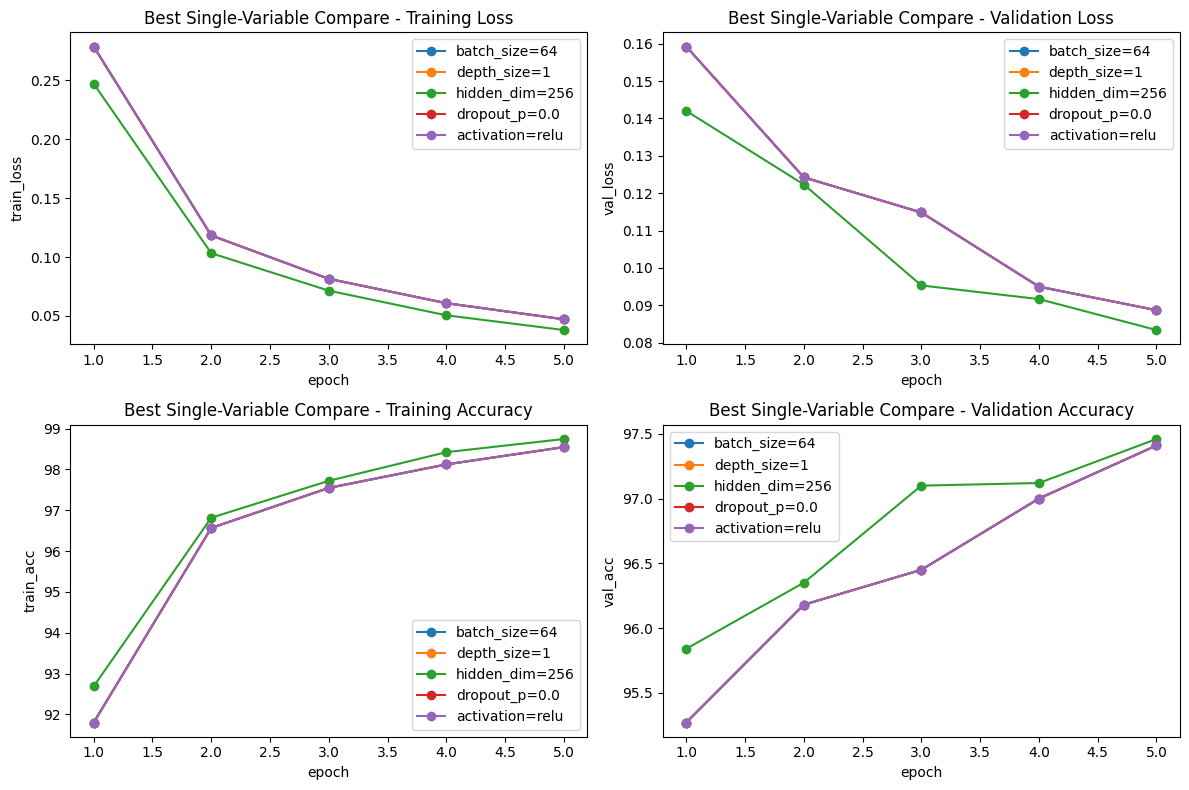

In [21]:
plot_compare_grid(histories, title_prefix="Best Single-Variable Compare")

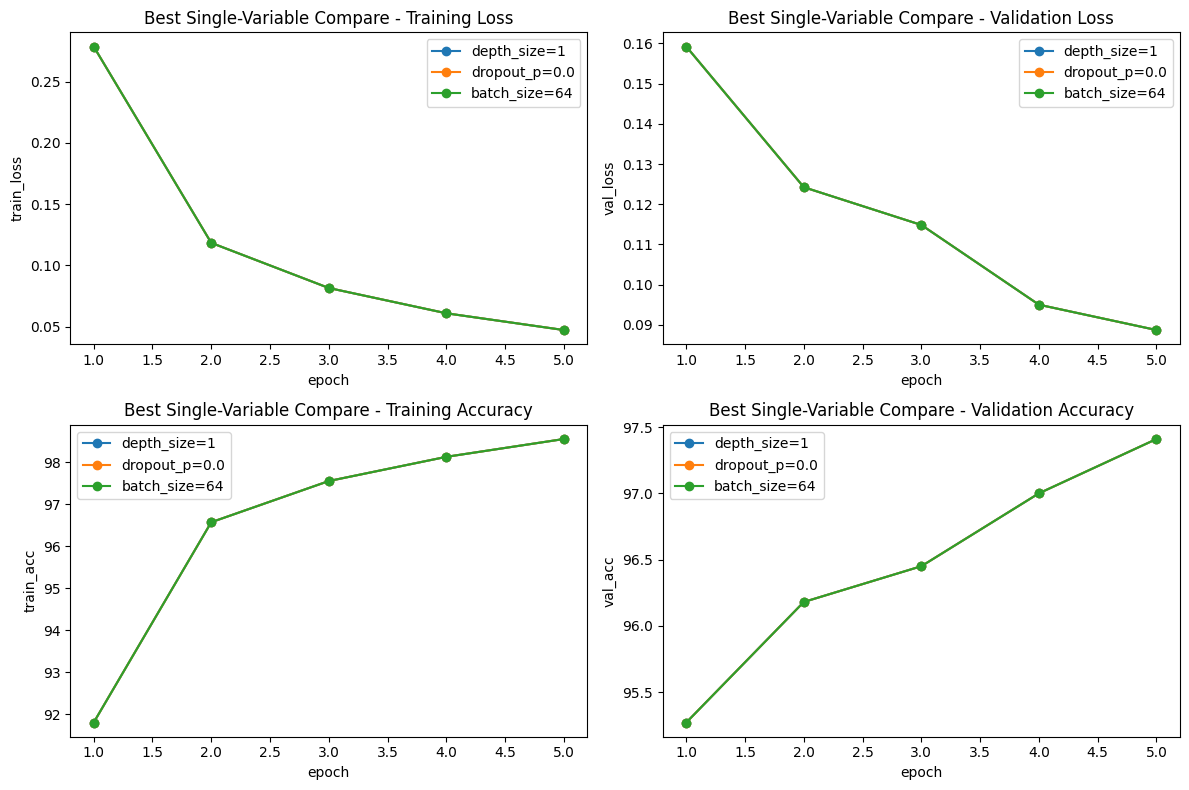

In [22]:
histories_2 ={
    "depth_size=1":history_ds_1,
    "dropout_p=0.0":history_dropout0,
    "batch_size=64":history_bs_64
}
plot_compare_grid(histories_2, title_prefix="Best Single-Variable Compare")

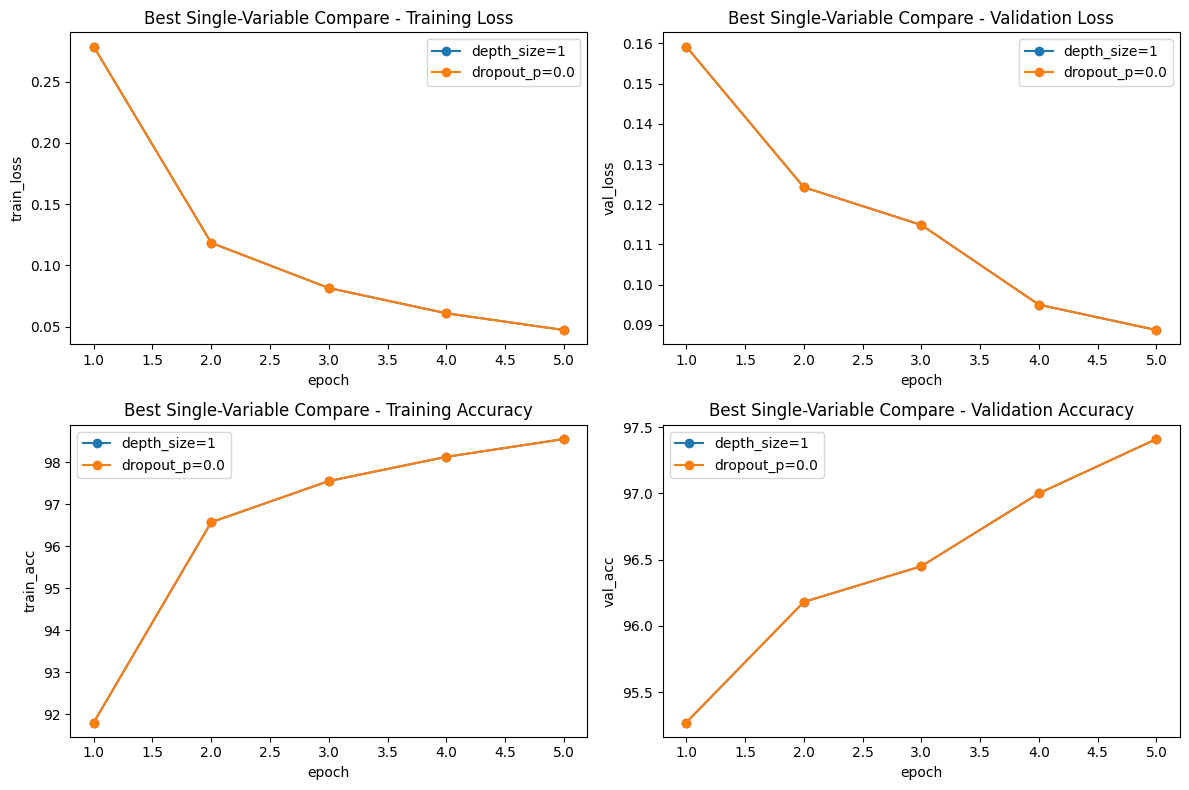

In [23]:
histories_3 ={
    "depth_size=1":history_ds_1,
    "dropout_p=0.0":history_dropout0,
}
plot_compare_grid(histories_3, title_prefix="Best Single-Variable Compare")

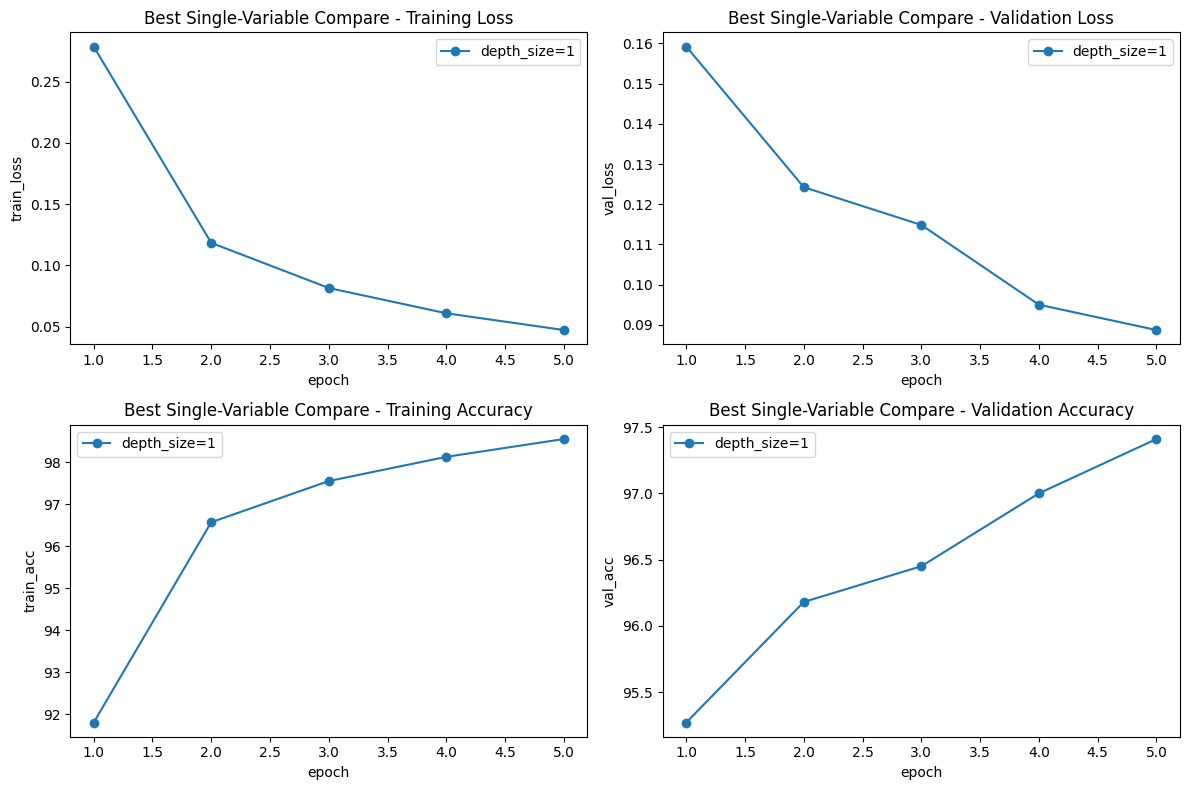

In [24]:
histories_4 ={
    "depth_size=1":history_ds_1,

}
plot_compare_grid(histories_4, title_prefix="Best Single-Variable Compare")

### 思考与分析

完成本练习后，可以思考下面几个问题：

- 不同调参方向中，哪一类改动对模型性能影响最明显？
- 收敛速度更快的模型，最终验证效果是否一定更好？
- 训练集准确率更高，是否一定代表模型泛化能力更强？

### 最终测试

完成调参后，选择验证集表现较好的模型，在测试集上评估一次。  
把最终测试准确率写入实验报告。


In [11]:
# TODO : 请把下面参数改成你最终选择的模型设置。
#最终选择hidden_dim=256

final_model, final_history, final_test_loader = run_experiment(
    exp_name="final_model",
    batch_size=64,
    hidden_dims=[256],
    activation_name="relu",
    dropout_p=0.0,
    learning_rate=0.001,
    epochs=5,
    verbose=True,
)

criterion = nn.CrossEntropyLoss()
final_test_loss, final_test_acc = evaluate(final_model, final_test_loader, criterion)

print("\n最终模型最后 3 个 epoch 结果：")
print_history_table(final_history, last_n=3)

print(f"Final test loss: {final_test_loss:.4f}")
print(f"Final test accuracy: {final_test_acc:.2f}%")


实验名称: final_model
batch_size: 64
hidden_dims: [256]
activation_name: relu
dropout_p: 0.0
learning_rate: 0.001
epochs: 5
Epoch 01/5 | train_loss=0.2469, train_acc=92.70% | val_loss=0.1418, val_acc=95.87% | time=15.39s
Epoch 02/5 | train_loss=0.1033, train_acc=96.90% | val_loss=0.1243, val_acc=96.19% | time=14.75s
Epoch 03/5 | train_loss=0.0710, train_acc=97.75% | val_loss=0.0937, val_acc=97.13% | time=14.18s
Epoch 04/5 | train_loss=0.0506, train_acc=98.39% | val_loss=0.0926, val_acc=97.04% | time=14.01s
Epoch 05/5 | train_loss=0.0372, train_acc=98.75% | val_loss=0.0848, val_acc=97.41% | time=14.19s
训练总耗时: 72.52 秒

最终模型最后 3 个 epoch 结果：
epoch | train_loss | train_acc | val_loss | val_acc | time(s)
-------------------------------------------------------------
    3 |     0.0710 |    97.75% |   0.0937 |  97.13% |   14.18
    4 |     0.0506 |    98.39% |   0.0926 |  97.04% |   14.01
    5 |     0.0372 |    98.75% |   0.0848 |  97.41% |   14.19
Final test loss: 0.0752
Final test accuracy: 97.

## 四、附加题（选做）



**选做附加题3**


### 附加题 1：联合调参探索

要求：在前面单变量调参实验的基础上，**同时调整多个参数**，设计新的模型配置，并与基线模型或单变量实验结果进行对比。

提示：
- 可尝试组合各类实验中表现较好的参数设置；
- 例如同时调整 batch size、网络深度、神经元数量、激活函数、Dropout 等。

注意：
- 前面选出的“最佳单变量结果”，是在其他参数保持基线不变的前提下得到的。
- 因此，各类实验中分别选出的最佳设置，直接组合后不一定仍然是最优模型；有时效果可能更好，也可能变差。
- 本题重在观察联合调参后的效果变化，并做简要分析。

In [ ]:
# TODO：选做。
# 尝试联合调参：同时修改多个参数，设计新的模型配置。


### 附加题 2：数据增强

要求：只**对训练集使用数据增强**，验证集和测试集不要使用随机增强。

因为验证/测试阶段需要使用稳定、可重复的数据来客观评估模型性能。

可以尝试：

- `transforms.RandomRotation(...)`
- `transforms.RandomCrop(...)`
- 其他合理的图像增强方法

观察增强前后验证集或测试集准确率的变化。


In [ ]:
# TODO：选做。
# 只给训练集添加随机增强，验证集和测试集仍使用普通 transform。


### 附加题 3：自定义网络结构

要求：设计一个**不同于基础全连接 BP 网络的模型**，并与基线模型对比。

可以任选一种方向：

- 加入 BatchNorm
- 加入卷积层 Conv2d 和池化层 MaxPool2d
- 设计更深或更宽的网络
- 尝试残差连接等拓展结构

注意：不要求全部实现，任选一种合理扩展即可。


#### Setup


In [24]:
# TODO：选做。
# 自定义一个不同于基础全连接 BP 网络的模型，并比较验证集/测试集表现。

from tqdm.auto import tqdm

#ResNet使用了BN,可以让训练集上drop_last=True; 使用GPU时num_workers设置为2,pin_memory=True
def Make_dataloaders(batch_size,pin_memory=False,drop_last=False,num_workers=0):
    """根据 batch_size 创建训练集、验证集和测试集 DataLoader。
    drop_last:仅影响训练集
    """
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                              pin_memory=pin_memory,drop_last=drop_last,num_workers=num_workers)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False,
                            pin_memory=pin_memory,num_workers=num_workers)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False,
                             pin_memory=pin_memory,num_workers=num_workers)
    return train_loader, val_loader, test_loader

##修改run_experiment,新增model参数; 使用余弦学习率调度器;使用weight_decay进行正则化
def Run_experiment(
    model,
    exp_name="baseline",
    model_name=None,
    batch_size=64,
    learning_rate=0.001,
    weight_decay=1e-4,
    epochs=20,  #epochs 修改为20~30
    verbose=True,
    pin_memory=True,  #默认使用GPU
    drop_last=True,  #使用BN默认drop_last=True(仅影响训练集)
    num_workers=2):  #设置训练集、验证集、测试集的num_workers数量
    """
    运行一组实验。

    返回：
    - model: 训练好的模型
    - history: 每个 epoch 的训练/验证结果
    - test_loader: 测试集加载器，供后续最终评估使用
    """

    # 每组实验重新固定随机种子，减少随机因素影响。
    set_seed(SEED)

    # 根据参数创建数据、模型、损失函数和优化器。
    train_loader, val_loader, test_loader = Make_dataloaders(batch_size,pin_memory=pin_memory,
                                                             drop_last=drop_last,
                                                             num_workers=num_workers)
    model=model.to(device)
    criterion = nn.CrossEntropyLoss()
    #使用weight_decay
    optimizer = optim.Adam(model.parameters(), lr=learning_rate,weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs) #余弦学习率调度器
    history = init_history()

    if verbose:
        print("=" * 72)
        print("实验名称:", exp_name)
        if model_name is not None:
          print("使用模型",model_name)
        print("batch_size:", batch_size)
        print("learning_rate:", learning_rate)
        print("epochs:", epochs)
        print("=" * 72)

    for epoch in tqdm(range(1, epochs + 1),desc=f"{epochs} epochs total"):
        start_time = time.time()

        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        val_loss, val_acc = evaluate(model, val_loader, criterion)

        scheduler.step() #学习率调度器更新

        epoch_time = time.time() - start_time
        record_history(history, epoch, train_loss, train_acc, val_loss, val_acc, epoch_time)

        if verbose:
            print(
                f"Epoch {epoch:02d}/{epochs} | "
                f"train_loss={train_loss:.4f}, train_acc={train_acc:.2f}% | "
                f"val_loss={val_loss:.4f}, val_acc={val_acc:.2f}% | "
                f"time={epoch_time:.2f}s"
            )

    if verbose:
        print(f"训练总耗时: {sum(history['epoch_time']):.2f} 秒")

    return model, history, test_loader






#### 模型定义: CNN ,Res34 Res50 for MNIST



##### CNN baseLine

In [15]:
class TinyCNN(nn.Module):
    """极简基线：2 层卷积，~0.03M 参数"""
    def __init__(self, in_channels=1, num_classes=10):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),  # →14
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),            # →7
        )
        self.fc = nn.Linear(32 * 7 * 7, num_classes)

    def forward(self, x):
        x = self.conv(x)
        x = torch.flatten(x, 1)
        return self.fc(x)


##### Res34 for MNIST

In [16]:
class BasicBlock(nn.Module):
    """
    input: x (N,C,H,W), H==W
    两个卷积层
    常规卷积层为3*3,stride=1,padding=1
    保持通道数与尺寸不变
    残差连接:直接相加

    如果down_sampling=True
    则第一个卷积层为3*3,stride=2,padding=1
    使得通道数加倍,尺寸减半
    且残差连接使用1*1卷积;

    """
    def __init__(self,out_channels,down_sampling=False):
        """
        down_sampling:是否进行下采样,i.e.,通道数加倍,尺寸图减半
        out_channels:代表该Stage的channels
        如果down_sampling=True
        则in_channels=out_channels/2
        否则in_channels=out_channels
        """
        super().__init__()

        self.down_sampling=down_sampling
        in_channels= out_channels//2 if self.down_sampling else out_channels
        stride= 2 if self.down_sampling else 1
        self.Conv1 = nn.Conv2d(in_channels,out_channels,
                               kernel_size=3,stride=stride,padding=1,
                               bias=False)
        self.BN1 = nn.BatchNorm2d(out_channels)
        self.Conv2 = nn.Conv2d(out_channels,out_channels,
                               kernel_size=3,stride=1,padding=1,
                               bias=False)
        #第二个常规卷积的stride总为1
        self.BN2 = nn.BatchNorm2d(out_channels)
        if self.down_sampling:
            self.projection = nn.Conv2d(in_channels,out_channels,
                                       kernel_size=1,stride=2,padding=0,
                                       bias=False)
            #注意,stride=2,因为此时特征图尺寸减半
            #对于偶数,返回H/2;对于奇数,返回(H+1)/2
            self.BN3 = nn.BatchNorm2d(out_channels)




    def forward(self,x):
        y = F.relu(self.BN1(self.Conv1(x)))
        y = self.BN2(self.Conv2(y))
        if self.down_sampling:
            x = self.BN3(self.projection(x))
        return F.relu(y+x)


In [17]:
class Res34(nn.Module):
    def __init__(self,in_channels=1):
        """
        Res34 for MNIST Classification
        input: image of shape (N,1,28,28)
        output: predict one of 10 class

        Stem:
        3*3, stride=1,padding=1,out_channels=64
        BatchNorm2d ->ReLU
        No MaxPooling Layer

        channels: 64->128->256->512  size: 28 14 7 4
        4 Residual Stages
        #BasicBlocks: 3,4,6,3
        Stage1 <--> Conv2_x
        Stage2 <--> Conv3_x
        Stage3 <--> Conv4_x
        Stage4 <--> Conv5_x

        Stage4 输出的张量形状为(N,512,4,4)
        """
        super().__init__()
        self.in_channels=in_channels
        self.stage1_c,self.stage1_num = 64 , 3
        self.stage2_c, self.stage2_num = 128, 4
        self.stage3_c, self.stage3_num = 256, 6
        self.stage4_c, self.stage4_num = 512, 3

        self.stem = nn.Sequential(*[nn.Conv2d(self.in_channels,self.stage1_c,
                                kernel_size=3,stride=1,padding=1,
                                bias=False ),
                                 nn.BatchNorm2d(self.stage1_c),
                                  nn.ReLU() ])
        #由于使用MNIST,Stage1不需要进行down_sampling(原本需要经过max_pooling)
        self.stage1 = nn.Sequential(*[BasicBlock(self.stage1_c)
                                     for i in range(self.stage1_num)
        ])

        self.stage2= nn.Sequential(*([BasicBlock(self.stage2_c,down_sampling=True)]+
                                     [BasicBlock(self.stage2_c) for i in range(self.stage2_num-1)]))
        self.stage3 = nn.Sequential(*([BasicBlock(self.stage3_c,down_sampling=True)]+
                                     [BasicBlock(self.stage3_c) for i in range(self.stage3_num-1)]))
        self.stage4 =  nn.Sequential(*([BasicBlock(self.stage4_c,down_sampling=True)]+
                                     [BasicBlock(self.stage4_c) for i in range(self.stage4_num-1)]))
        """
        alternative:记录self.stage_num,把self.stage{i}_c,self.stage{i}_num;
        self.stage{i}分别封装为列表
        """
        self.stages=nn.Sequential(self.stage1,self.stage2,self.stage3,self.stage4)

        #最终得到特征图形状为(N,512,4,4)
        self.avgpool = nn.AdaptiveAvgPool2d((1,1))  #alternative : nn.AvgPool2d (kernel_size=4)
        self.fc = nn.Linear(self.stage4_c,10) #10分类问题


    def forward(self,x):
        y = self.stem(x)
        y = self.stages(y)
        y = self.avgpool(y)
        y = torch.flatten(y,1)  #注意展平,avgpool返回(N,C,1,1)
        y = self.fc(y)
        return y




##### Res50

In [18]:
class BottleNeck(nn.Module):
    def __init__(self,out_channels,down_sampling=False,first_stage=False):
        """
        降维:1*1,stride=1,padding=0,in_channels=out_channels/4 if down_sampling
        卷积:3*3,stride=2 或 1,padding=1
        升维:1*1,stride=1,padding=0
        channels:
        out_channels/4->out_channels/4->out_channels

        Res50: out_channels= 256, 512, 1024, 2048

        由于经过Res50的Stem后图片的通道数为64,
        而Stage1的通道数为256,
        实际上输入通道数不满足输出通道数除以2;
        此时in_channels= out_channels/4
        因此first_stage标志用于特殊处理Stage1的情况
        """
        super().__init__()
        #保存forward()中需要使用的变量
        self.down_sampling=down_sampling
        self.first_stage=first_stage

        in_channels = out_channels//4 if first_stage else out_channels//2 if self.down_sampling else out_channels

        stride=1 if first_stage else 2 if self.down_sampling else 1
        #如果是Stage1,那么不进行下采样

        self.Conv1= nn.Conv2d(in_channels,out_channels//4,
                            kernel_size=1,stride=1,padding=0)
        self.BN1 = nn.BatchNorm2d(out_channels//4)

        self.Conv2 = nn.Conv2d(out_channels//4,out_channels//4,
                               kernel_size=3,stride=stride,padding=1)
        #由中间卷积层负责下采样(如果进行下采样的话)
        self.BN2 = nn.BatchNorm2d(out_channels//4)

        self.Conv3 = nn.Conv2d(out_channels//4,out_channels,
                                kernel_size=1,stride=1,padding=0)
        self.BN3 = nn.BatchNorm2d(out_channels)


        """
        无论下采样还是first_stage的第一层,都需要投影
        对于下采样,输入输出的尺寸与通道数都不同
        对于first_stage的第一层,输入输出的尺寸相同
        但通道数不同
        """
        if self.down_sampling or self.first_stage:
            self.projection = nn.Conv2d(in_channels,out_channels,
                                        kernel_size=1,stride=stride,padding=0)
            #下采样时:stride=2
            self.BN4=nn.BatchNorm2d(out_channels)




    def forward(self,x):
        y = F.relu(self.BN1(self.Conv1(x)))
        y = F.relu(self.BN2(self.Conv2(y)))
        y = self.BN3(self.Conv3(y))
        if self.down_sampling or self.first_stage:
            x = self.BN4(self.projection(x))
        return F.relu(y+x)


In [19]:
class Res50(nn.Module):
    """
    Res50 for MNIST
    channels: 256, 512, 1024, 2048
    size:28 -> 14 -> 7 ->4

    Stem:
    3*3,stride=1,padding=1,out_channels=64
    No MaxPooling

    Stage1->Stage2->Stage3->Stage4->GAP+Linear

    Stage1: C_in:64 C_out:256
    Stage1的第一个BottleNeck的第一层卷积的输入通道需要特殊处理
    此时C_in≠C_out//2,而是C_out//4

    """
    def __init__(self,in_channels=1):
        super().__init__()
        self.in_channels=in_channels
        self.stem_c=64
        self.stage1_c,self.stage1_num=256,3
        self.stage2_c,self.stage2_num=512,4
        self.stage3_c,self.stage3_num=1024,6
        self.stage4_c,self.stage4_num=2048,3

        self.stem= nn.Sequential(*[nn.Conv2d(in_channels,self.stem_c,
                                            kernel_size=3,stride=1,padding=1,
                                            bias=False),
                                    nn.BatchNorm2d(self.stem_c),
                                    nn.ReLU()
                             ])
        self.stage1=nn.Sequential(*([BottleNeck(self.stage1_c,first_stage=True)]+
                                    [BottleNeck(self.stage1_c) for i in range(self.stage1_num -1)]))
        self.stage2=nn.Sequential(*([BottleNeck(self.stage2_c,down_sampling=True)]+
                                    [BottleNeck(self.stage2_c) for i in range(self.stage2_num-1)]))
        self.stage3=nn.Sequential(*([BottleNeck(self.stage3_c,down_sampling=True)]+
                                    [BottleNeck(self.stage3_c) for i in range(self.stage3_num-1)]))
        self.stage4=nn.Sequential(*([BottleNeck(self.stage4_c,down_sampling=True)]+
                                    [BottleNeck(self.stage4_c) for i in range(self.stage4_num-1)]))
        self.stages=nn.Sequential(self.stage1,self.stage2,self.stage3,self.stage4)

        self.avgpool=nn.AdaptiveAvgPool2d((1,1))
        self.fc=nn.Linear(self.stage4_c,10)

    def forward(self,x):
        y =self.stem(x)
        y = self.stages(y)
        y = self.avgpool(y)
        y = torch.flatten(y,1)
        y = self.fc(y)
        return y



In [ ]:
####

#### 模型保存

In [12]:
import pickle

In [13]:
SAVE_DIR = "/content/drive/MyDrive/ML_lab/lab2/checkpoints"
os.makedirs(SAVE_DIR, exist_ok=True)

In [14]:
# ==================== 保存 ====================
def save_checkpoint(model, history, model_name, save_dir=SAVE_DIR):
    """
    保存模型权重 + 训练历史
    参数：
    - model:      model (已训练好的实例, e.g. Res34())
    - history:    dict, 训练历史
    - model_name: str,  "Res34" / "TinyCNN" / "Baseline" 等
    - save_dir:   保存目录
    """
    os.makedirs(save_dir, exist_ok=True)
    # ① 保存模型权重
    model_path = os.path.join(save_dir, f"{model_name}_weights.pth")
    torch.save(model.state_dict(), model_path)
    # ② 保存训练历史
    history_path = os.path.join(save_dir, f"{model_name}_history.pkl")
    with open(history_path, "wb") as f:
        pickle.dump(history, f)
    print(f" {model_name} 已保存 → {save_dir}/")
# ==================== 加载 ====================
def load_checkpoint(model_class, model_name, save_dir=SAVE_DIR):
    """
    加载模型权重 + 训练历史
    参数：
    - model_class: 类名（不是实例），e.g. Res34, TinyCNN, SimpleCNN
    - model_name:  str,  "Res34" / "TinyCNN" 等
    返回：
    - model:   已加载权重的模型（eval 模式）
    - history: 训练历史 dict
    使用示例：
        model_34, hist_34 = load_checkpoint(Res34, "Res34")
    """
    # ① 创建空模型，加载权重
    model = model_class()
    model_path = os.path.join(save_dir, f"{model_name}_weights.pth")
    if not os.path.exists(model_path):
        raise FileNotFoundError(f"找不到权重文件: {model_path}")
    model.load_state_dict(torch.load(model_path, map_location="cpu"))
    model.eval()
    # ② 加载历史
    history_path = os.path.join(save_dir, f"{model_name}_history.pkl")
    if not os.path.exists(history_path):
        raise FileNotFoundError(f"找不到历史文件: {history_path}")
    with open(history_path, "rb") as f:
        history = pickle.load(f)
    print(f" {model_name} 已加载")
    return model, history
# ==================== 一键保存所有 histories ====================
def save_all_histories(histories_dict, filename="all_histories.pkl", save_dir=SAVE_DIR):
    """把整个 histories 字典保存为一个文件"""
    path = os.path.join(save_dir, filename)
    with open(path, "wb") as f:
        pickle.dump(histories_dict, f)
    print(f" 全部历史已保存 → {path}")
def load_all_histories(filename="all_histories.pkl", save_dir=SAVE_DIR):
    """加载整个 histories 字典"""
    path = os.path.join(save_dir, filename)
    if not os.path.exists(path):
        raise FileNotFoundError(f"找不到文件: {path}")
    with open(path, "rb") as f:
        histories = pickle.load(f)
    print(f" 全部历史已加载 ({len(histories)} 个模型)")
    return histories

#### 训练

In [17]:
histories= {}

In [24]:
##baseline

baseline,history_bl,_ = Run_experiment(
    model=build_mlp([128],'relu', 0.0),
    exp_name="BaseLine",
    model_name="BaseLine",
    batch_size=64,
    learning_rate=0.001,
    weight_decay=1e-4,
    epochs=20,
    verbose=False,
)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


20 epochs total:   0%|          | 0/20 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [26]:
histories['baseline']=history_bl

In [33]:
save_checkpoint(baseline, history_bl, "Baseline")

 Baseline 已保存 → /content/drive/MyDrive/ML_lab/lab2/checkpoints/


In [27]:
#TinyCNN
cnn,history_cnn,_ = Run_experiment(
    model=TinyCNN(),
    exp_name="TinyCNN",
    model_name="TinyCNN",
    batch_size=64,
    learning_rate=0.001,
    weight_decay=1e-4,
    epochs=20,
    verbose=False,
)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


20 epochs total:   0%|          | 0/20 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [28]:
histories['TinyCNN']=history_cnn

In [34]:
save_checkpoint(cnn, history_cnn, "TinyCNN")

 TinyCNN 已保存 → /content/drive/MyDrive/ML_lab/lab2/checkpoints/


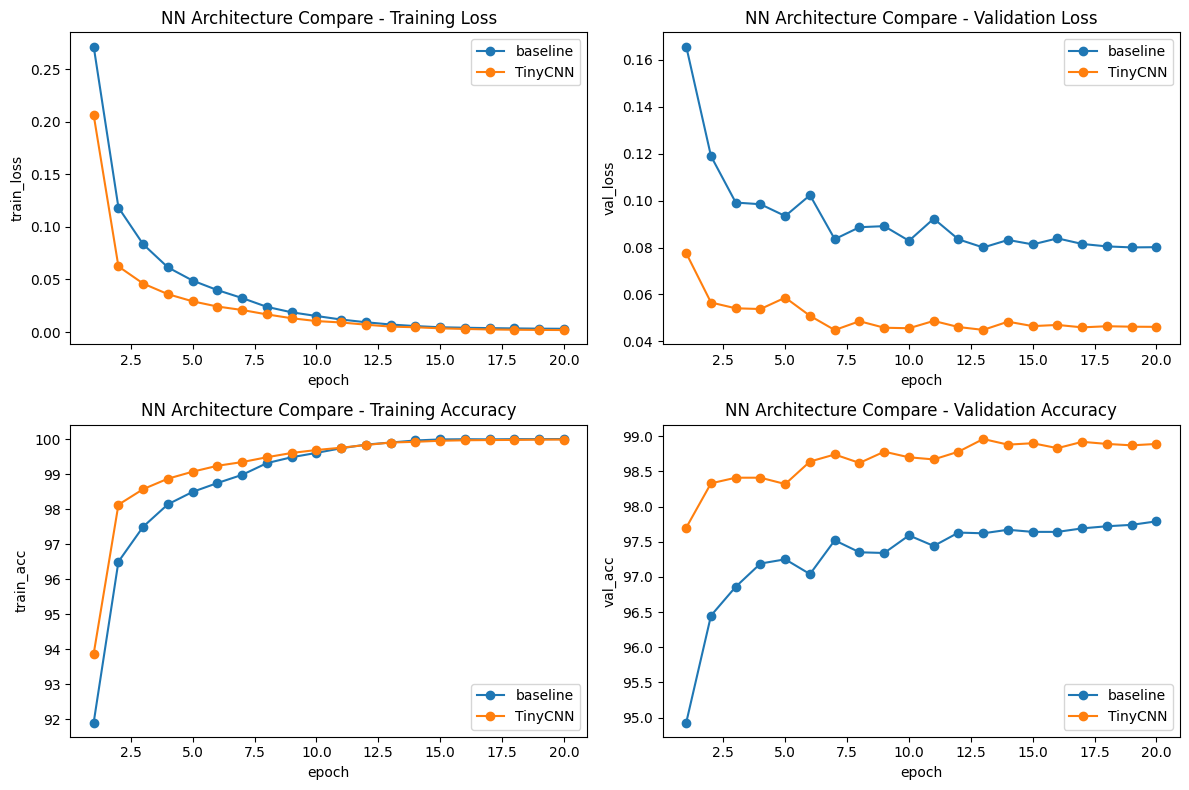

In [29]:
plot_compare_grid(histories, title_prefix="NN Architecture Compare")

In [35]:
save_all_histories(histories)
#保存部分历史

 全部历史已保存 → /content/drive/MyDrive/ML_lab/lab2/checkpoints/all_histories.pkl


In [20]:
histories = load_all_histories()   #取回已有历史

 全部历史已加载 (2 个模型)


In [25]:
## Res34

model_34,history_res34,_= Run_experiment(
    model=Res34(),
    exp_name="Res34",
    model_name="Res34",
    batch_size=64,
    learning_rate=0.001,
    weight_decay=1e-4,
    epochs=20,
    verbose=False,
)

20 epochs total:   0%|          | 0/20 [00:00<?, ?it/s]

In [26]:
histories['Res34']=history_res34

In [27]:
save_checkpoint(model_34, history_res34, "Res34")

 Res34 已保存 → /content/drive/MyDrive/ML_lab/lab2/checkpoints/


In [28]:
## Res50

model_50,history_res50,_= Run_experiment(
    model=Res50(),
    exp_name="Res50",
    model_name="Res50",
    batch_size=64,
    learning_rate=0.001,
    weight_decay=1e-4,
    epochs=20,
    verbose=False,
)

20 epochs total:   0%|          | 0/20 [00:00<?, ?it/s]

In [29]:
histories['Res50']=history_res50

In [30]:
save_checkpoint(model_50, history_res50, "Res50")

 Res50 已保存 → /content/drive/MyDrive/ML_lab/lab2/checkpoints/


In [31]:
save_all_histories(histories)

 全部历史已保存 → /content/drive/MyDrive/ML_lab/lab2/checkpoints/all_histories.pkl


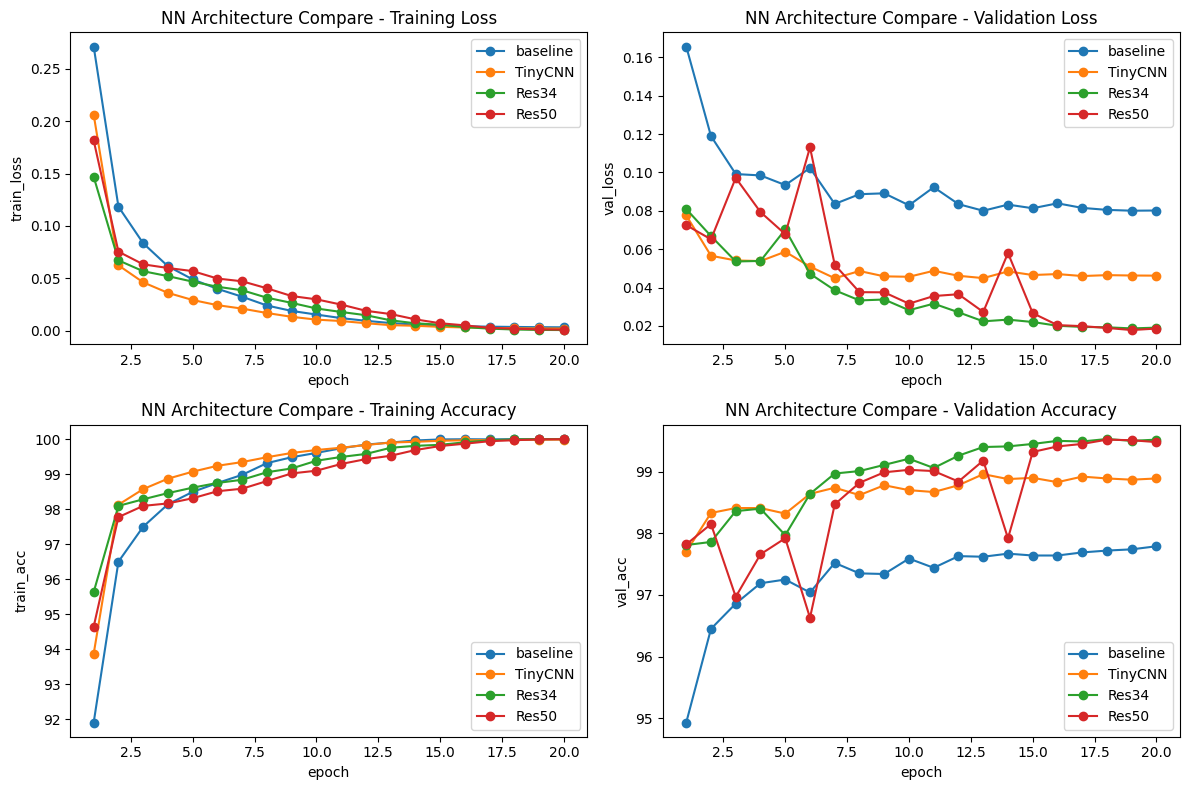

In [32]:
plot_compare_grid(histories, title_prefix="NN Architecture Compare")